In [21]:
# Imports 

import os
import pandas as pd
import numpy as np
from scipy.stats import shapiro, norm
from matplotlib import pyplot as plt
import time

In [22]:
# Directories and Global Variables
DATA_DIRECTORY = "./results"

# Retreive all Directories and files in the results 
QUALITY_DIRECTORIES = os.listdir(DATA_DIRECTORY)

In [23]:
files = []
for q in QUALITY_DIRECTORIES: 
    runs = os.listdir(f"{DATA_DIRECTORY}/{q}")
    for f in runs: 
        files.append(f"{q}/{f}")
files

['stable-volume/run_37.csv',
 'stable-volume/run_44.csv',
 'stable-volume/run_54.csv',
 'stable-volume/run_43.csv',
 'stable-volume/run_41.csv',
 'stable-volume/run_113.csv',
 'stable-volume/run_36.csv',
 'stable-volume/run_96.csv',
 'stable-volume/run_100.csv',
 'stable-volume/run_05.csv',
 'stable-volume/run_01.csv',
 'stable-volume/run_49.csv',
 'stable-volume/run_04.csv',
 'stable-volume/run_34.csv',
 'stable-volume/run_82.csv',
 'stable-volume/run_76.csv',
 'stable-volume/run_109.csv',
 'stable-volume/run_10.csv',
 'stable-volume/run_77.csv',
 'stable-volume/run_97.csv',
 'stable-volume/run_32.csv',
 'stable-volume/run_27.csv',
 'stable-volume/run_61.csv',
 'stable-volume/run_63.csv',
 'stable-volume/run_110.csv',
 'stable-volume/run_74.csv',
 'stable-volume/run_86.csv',
 'stable-volume/run_12.csv',
 'stable-volume/run_47.csv',
 'stable-volume/run_68.csv',
 'ambient-mode/run_20.csv',
 'ambient-mode/run_93.csv',
 'ambient-mode/run_78.csv',
 'ambient-mode/run_118.csv',
 'ambient-mod

In [24]:
example = pd.read_csv(f"{DATA_DIRECTORY}/{files[0]}")[['Time', 'SYSTEM_POWER (Watts)']]
first_time = example['Time'].iloc[0]
example['Time'] = example['Time'].apply(lambda x: (x - first_time) / 1000)
example.head(10)

,Time,SYSTEM_POWER (Watts)
0,0.000,8.527773
1,0.001,8.527773
2,0.211,8.527773
3,0.414,2.802814
4,0.617,2.802814
5,0.822,2.802814
6,1.025,2.802814
7,1.235,2.802814
8,1.441,2.488999
9,1.651,2.488999


In [25]:
# Check whether Data is normal

stats, p_val = shapiro(example['SYSTEM_POWER (Watts)'])

print(f"With p-val {p_val}, the data is {'NOT NORMAL' if p_val < 0.05 else 'NORMAL'}")

With p-val 1.559121230444645e-29, the data is NOT NORMAL


In [26]:
# Normalising the data

mean = example['SYSTEM_POWER (Watts)'].mean()
std = example['SYSTEM_POWER (Watts)'].std()
outlier = []
max_diff = 0
print(f"std: {3 * std}")
for idx, val in enumerate(example['SYSTEM_POWER (Watts)']): 
    diff = mean - val
    if np.abs(diff) > max_diff: max_diff = np.abs(diff) 
    if np.abs(diff) > 3*std: 
        print(f"Found outlier at {idx}")
        outlier.append(idx)

print(max_diff)
normalised_example = example.drop(index=outlier) 
normalised_example   


std: 2.083463190807162
Found outlier at 0
Found outlier at 1
Found outlier at 2
6.135235448339286


,Time,SYSTEM_POWER (Watts)
3,0.414,2.802814
4,0.617,2.802814
5,0.822,2.802814
6,1.025,2.802814
7,1.235,2.802814
...,...,...
288,59.326,2.420325
289,59.528,2.420325
290,59.738,2.420325
291,59.943,2.420325


Text(0, 0.5, 'System Power measurement (Watts)')

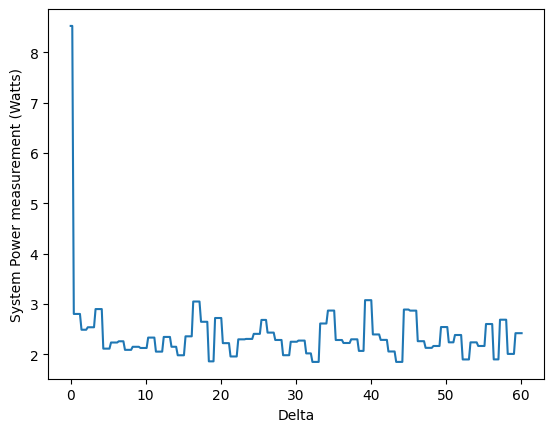

In [27]:
#Plotting data distribution
plt.plot(example['Time'], example['SYSTEM_POWER (Watts)'])
plt.xlabel("Delta")
plt.ylabel("System Power measurement (Watts)")

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x7fbb88793bc0>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x7fbb887cc5f0>,
 'cmins': <matplotlib.collections.LineCollection at 0x7fbb89a6a870>,
 'cbars': <matplotlib.collections.LineCollection at 0x7fbb89a6aea0>}

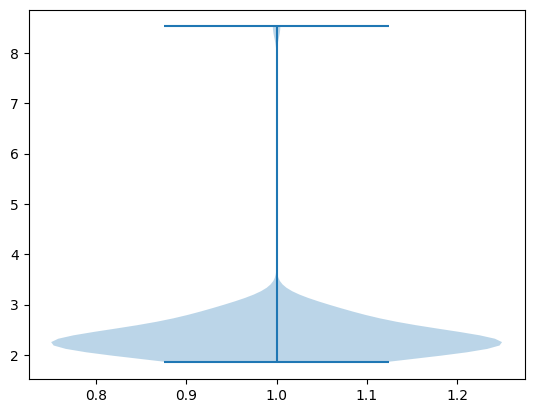

In [28]:
# Violin plots

plt.violinplot(example['SYSTEM_POWER (Watts)'])


### Creating a general setup to create combinations by subcategories 

The outlier removal didn't work, possibly becasue there are not enough sample. Might have to do something else. 

In [29]:
dataframes = {}
for f in files: 
    print(f"======== Converting file '{f}' ========")
    df = pd.read_csv(f"{DATA_DIRECTORY}/{f}")[['Time', 'SYSTEM_POWER (Watts)']]
    first_time = df['Time'].iloc[0]
    df['Time'] = df['Time'].apply(lambda x: (x - first_time) / 1000)
    dataframes[f] = df
    
dataframes[f]

======== Converting file 'stable-volume/run_37.csv' ========
======== Converting file 'stable-volume/run_44.csv' ========
======== Converting file 'stable-volume/run_54.csv' ========
======== Converting file 'stable-volume/run_43.csv' ========
======== Converting file 'stable-volume/run_41.csv' ========
======== Converting file 'stable-volume/run_113.csv' ========
======== Converting file 'stable-volume/run_36.csv' ========
======== Converting file 'stable-volume/run_96.csv' ========
======== Converting file 'stable-volume/run_100.csv' ========
======== Converting file 'stable-volume/run_05.csv' ========
======== Converting file 'stable-volume/run_01.csv' ========
======== Converting file 'stable-volume/run_49.csv' ========
======== Converting file 'stable-volume/run_04.csv' ========
======== Converting file 'stable-volume/run_34.csv' ========
======== Converting file 'stable-volume/run_82.csv' ========
======== Converting file 'stable-volume/run_76.csv' ========
======== Converting fi

,Time,SYSTEM_POWER (Watts)
0,0.000,2.110233
1,0.000,2.110233
2,0.211,2.110233
3,0.415,2.110233
4,0.625,2.110233
...,...,...
287,59.207,2.352857
288,59.417,2.352857
289,59.627,2.352857
290,59.830,1.994555


In [30]:
for f, df in dataframes.items():
    stats, p_val = shapiro(df['SYSTEM_POWER (Watts)'])

    print(f"With p-val {p_val}, the data in {f} is {'NOT NORMAL' if p_val < 0.05 else 'NORMAL'}\n==============================================================")

With p-val 1.559121230444645e-29, the data in stable-volume/run_37.csv is NOT NORMAL
With p-val 2.52763763775918e-06, the data in stable-volume/run_44.csv is NOT NORMAL
With p-val 3.22321311758483e-05, the data in stable-volume/run_54.csv is NOT NORMAL
With p-val 2.5813824738499214e-29, the data in stable-volume/run_43.csv is NOT NORMAL
With p-val 1.1146172224826685e-27, the data in stable-volume/run_41.csv is NOT NORMAL
With p-val 7.644053572058138e-10, the data in stable-volume/run_113.csv is NOT NORMAL
With p-val 2.147549982361054e-28, the data in stable-volume/run_36.csv is NOT NORMAL
With p-val 1.875179172008657e-12, the data in stable-volume/run_96.csv is NOT NORMAL
With p-val 3.947632226743026e-29, the data in stable-volume/run_100.csv is NOT NORMAL
With p-val 5.434527905601532e-29, the data in stable-volume/run_05.csv is NOT NORMAL
With p-val 3.0467174064119374e-25, the data in stable-volume/run_01.csv is NOT NORMAL
With p-val 2.1303803817140856e-12, the data in stable-volume/r

In [31]:
normalised_dataframes = {}
for f, df in dataframes.items(): 
    mean = df['SYSTEM_POWER (Watts)'].mean()
    std = df['SYSTEM_POWER (Watts)'].std()
    outlier = []
    max_diff = 0
    print(f"3x std: {3 * std} | mean: {mean}")
    for idx, val in enumerate(df['SYSTEM_POWER (Watts)']): 
        diff = mean - val
        abs = np.abs(diff)
        if abs > max_diff: max_diff = abs
        if abs > 3*std: 
            print(f"Found outlier at {idx}")
            outlier.append(idx)

    print(f"Maximum difference found: {max_diff}")
    n_df = df.drop(index=outlier) 
    normalised_dataframes[f] = n_df
    print("===============================================")

3x std: 2.083463190807162 | mean: 2.3925374551030965
Found outlier at 0
Found outlier at 1
Found outlier at 2
Maximum difference found: 6.135235448339286
3x std: 0.8987952647566778 | mean: 2.346496874968753
Maximum difference found: 0.6652454784705779
3x std: 0.8601583100409352 | mean: 2.3019124653241407
Maximum difference found: 0.6050797317126024
3x std: 2.0463704182265987 | mean: 2.404068791418759
Found outlier at 0
Found outlier at 1
Maximum difference found: 7.09341064736298
3x std: 1.8644563068998918 | mean: 2.394154773999567
Found outlier at 0
Found outlier at 1
Found outlier at 2
Maximum difference found: 5.225157989214544
3x std: 0.9822335231756589 | mean: 2.3035277136384624
Maximum difference found: 0.7729343167723042
3x std: 2.0420187697643373 | mean: 2.382209981141025
Found outlier at 0
Found outlier at 1
Found outlier at 2
Found outlier at 3
Maximum difference found: 5.123605048003262
3x std: 1.1199910601734615 | mean: 2.366233464789717
Found outlier at 11
Found outlier at

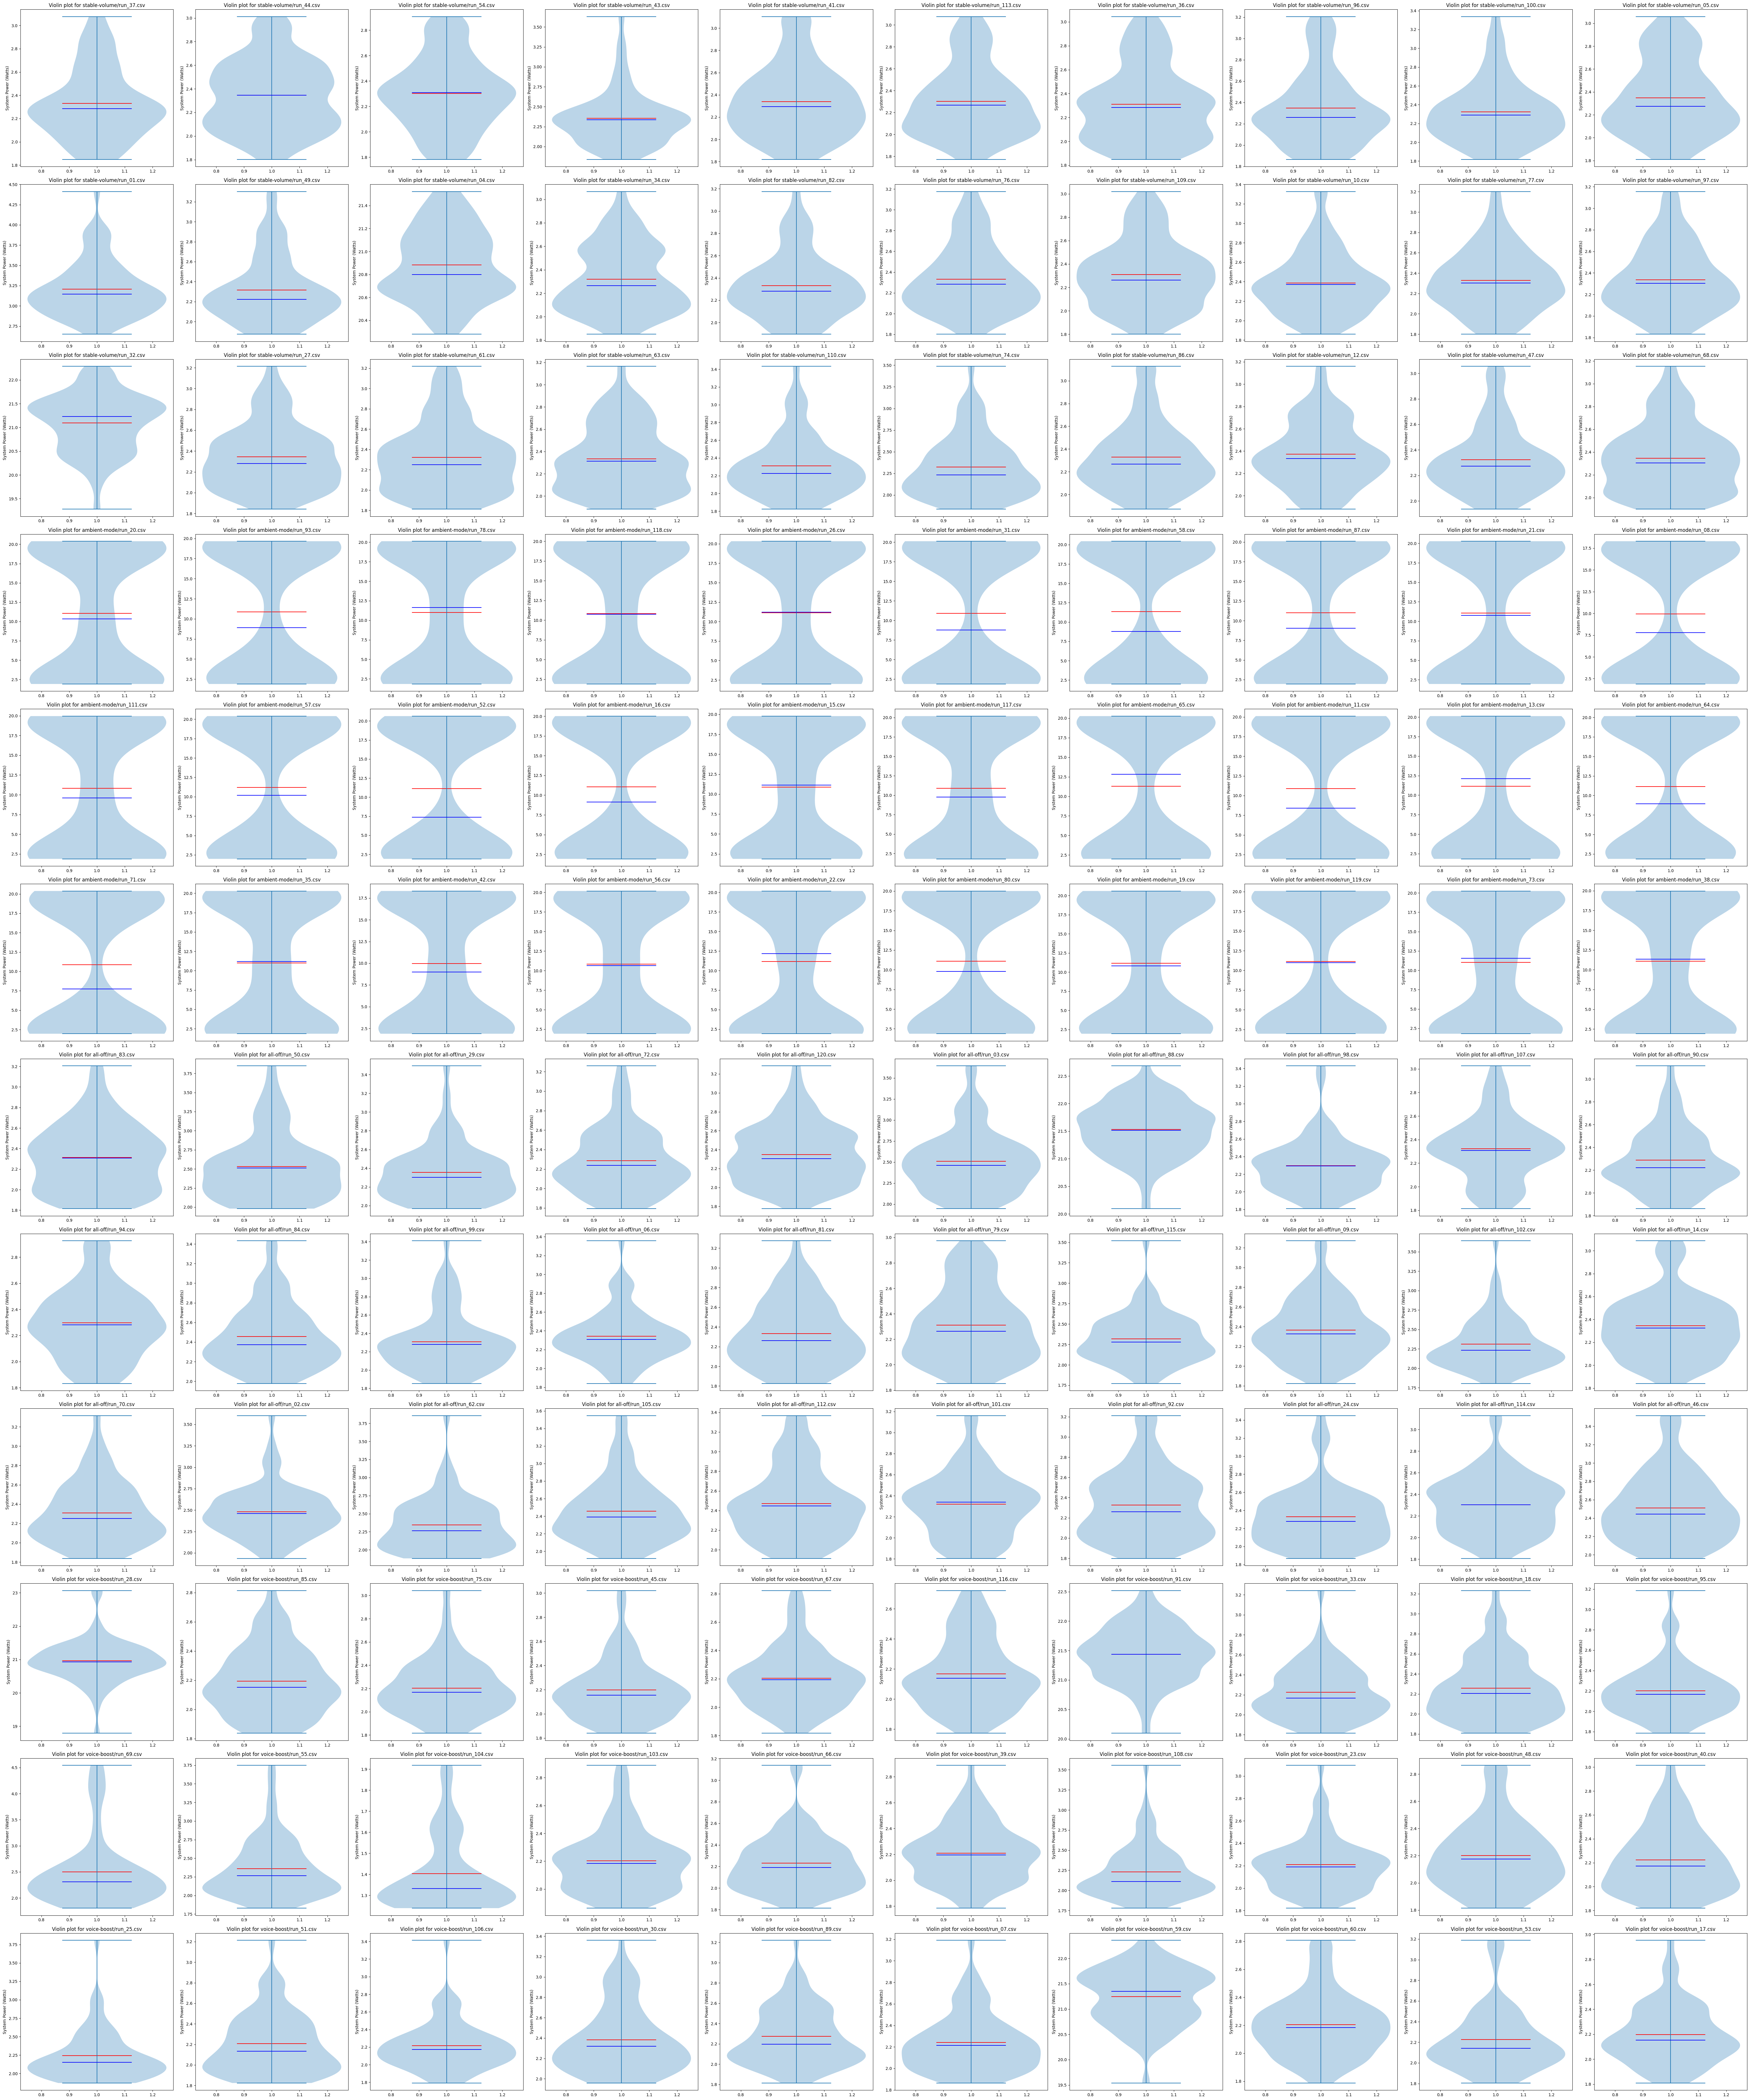

In [32]:
fig, plots = plt.subplots(nrows = 3 * len(QUALITY_DIRECTORIES), 
                               ncols = len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")) // 3,
                               figsize =(6 * len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")) // 3, 6 * len(QUALITY_DIRECTORIES) * 3))
plots = plots.flatten()

for idx, (f, df) in enumerate(normalised_dataframes.items()): 
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    parts = ax.violinplot(df['SYSTEM_POWER (Watts)'], showmeans=True, showmedians=True)
    parts['cmeans'].set_color('red')
    parts['cmedians'].set_color('blue')    

plt.tight_layout()
plt.show()

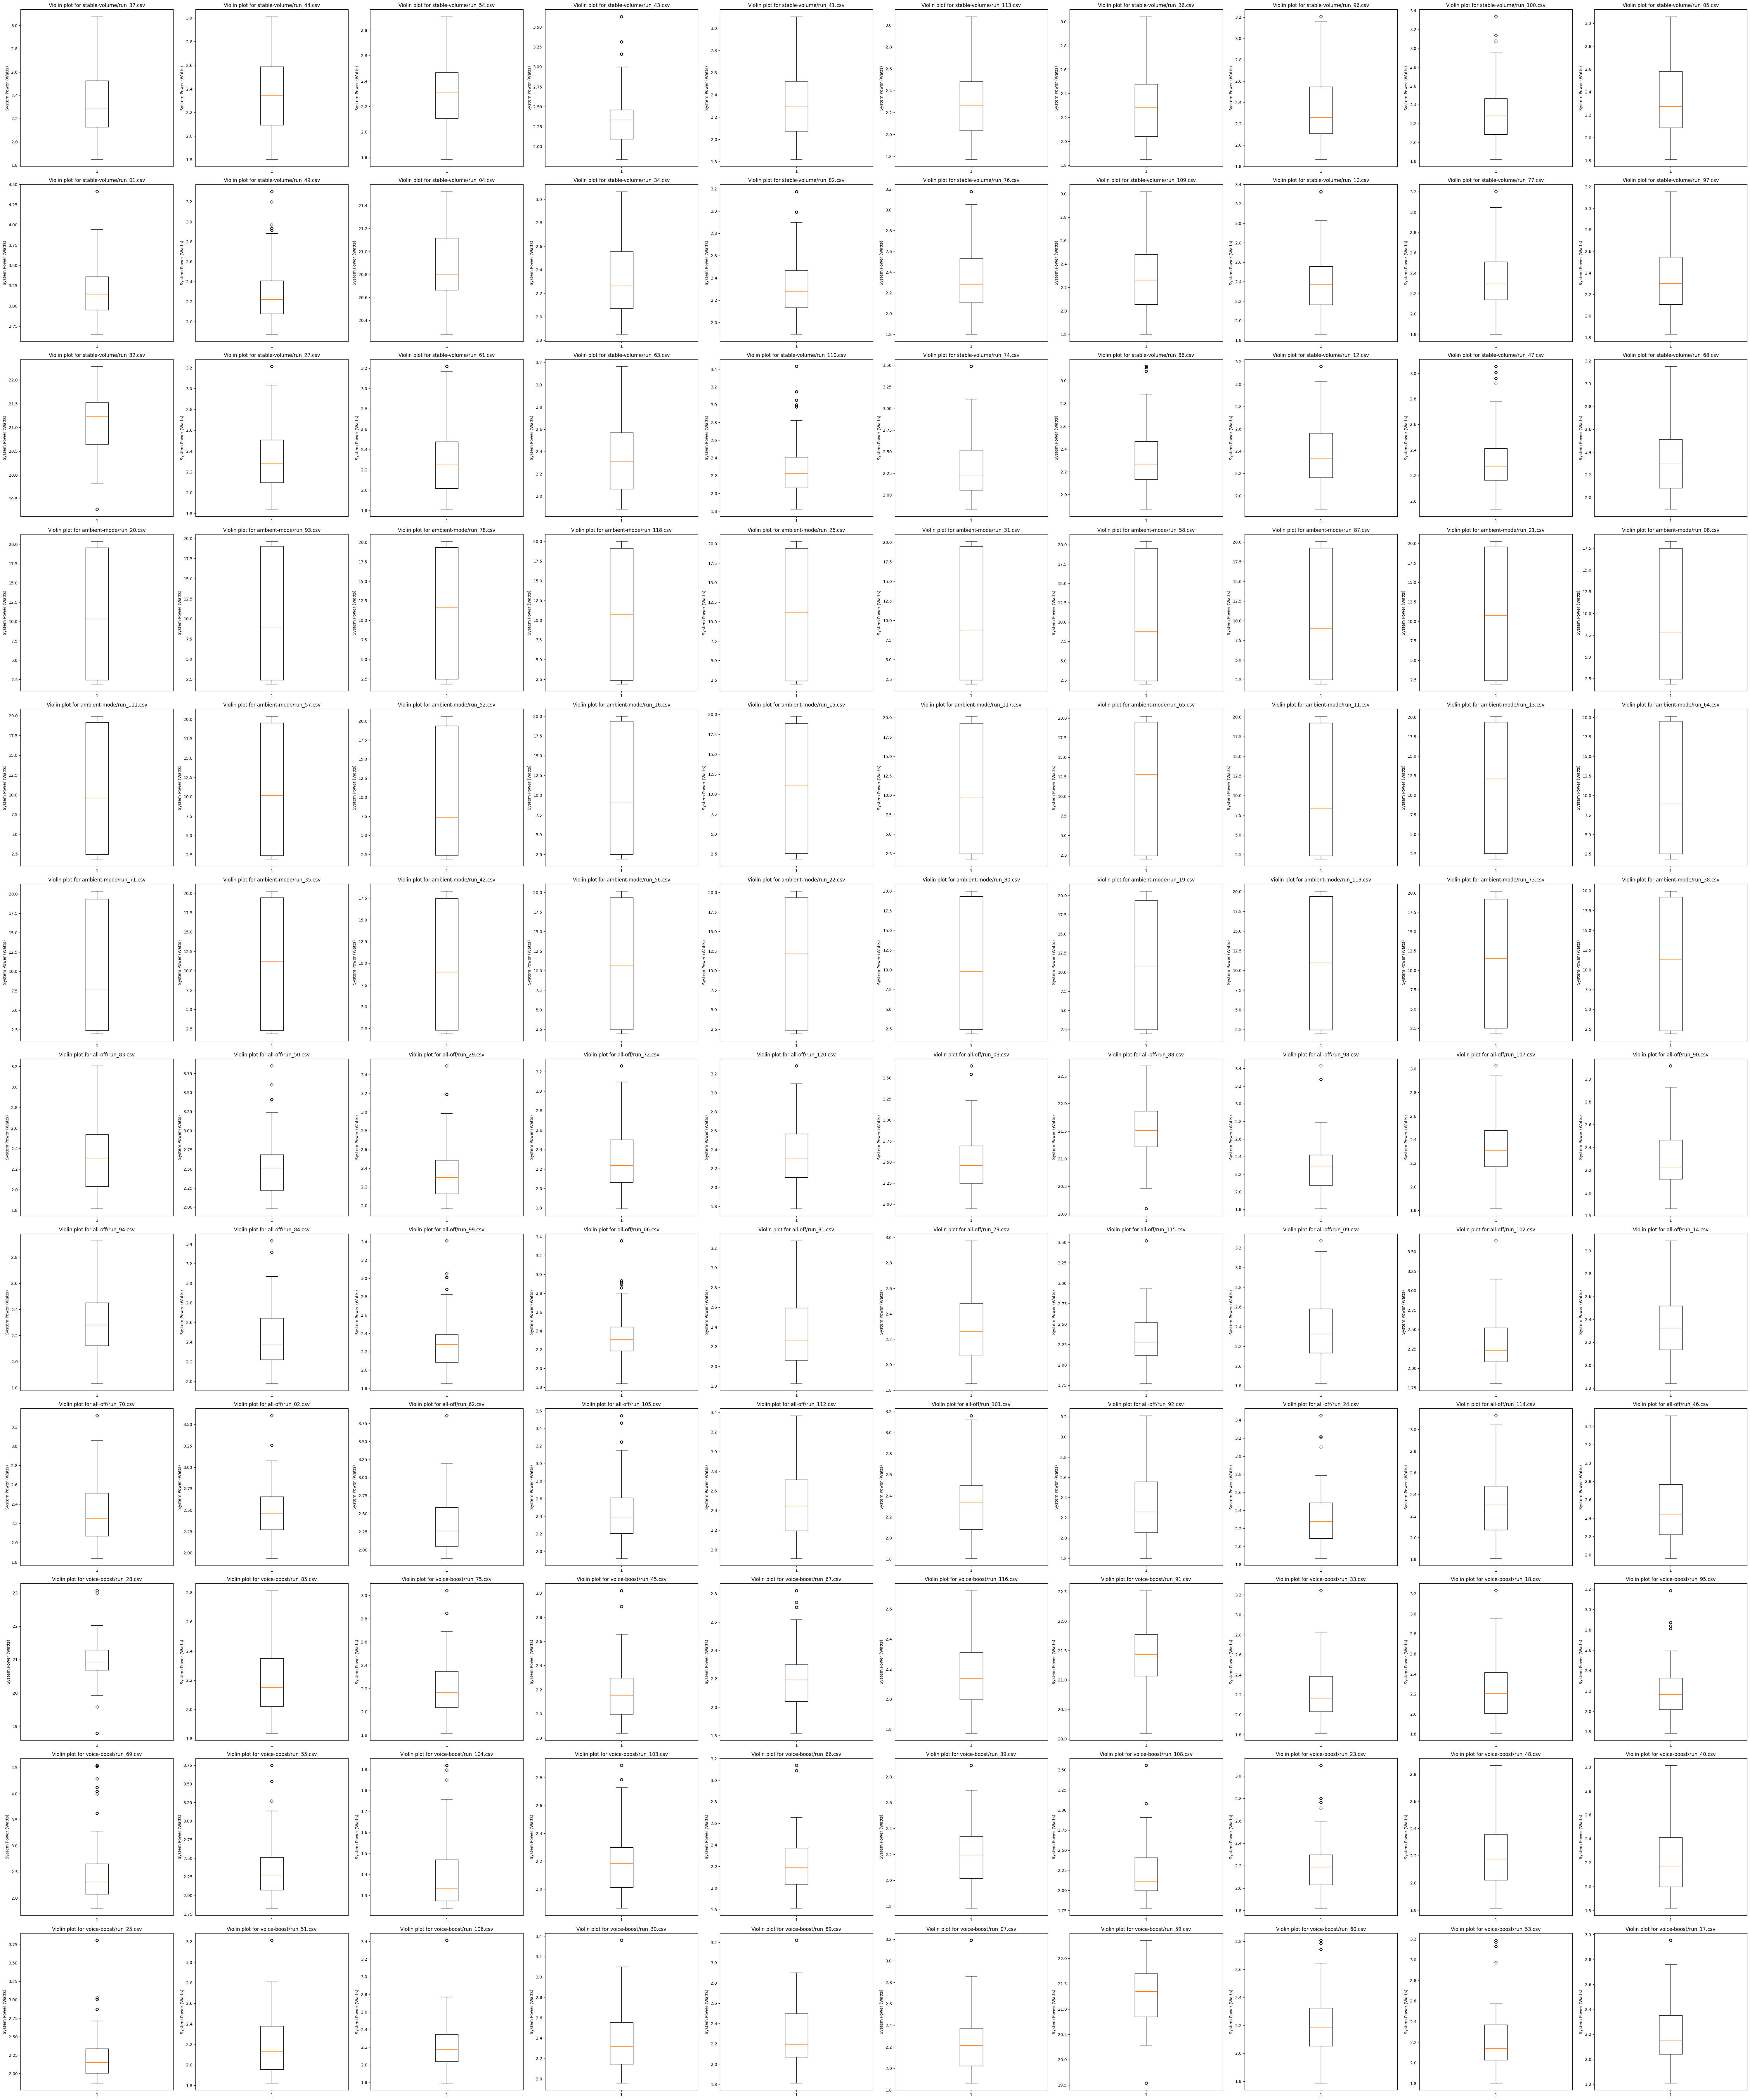

In [33]:
fig, plots = plt.subplots(nrows = 3 * len(QUALITY_DIRECTORIES), 
                               ncols = len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")) // 3,
                               figsize =(6 * len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")) // 3, 6 * len(QUALITY_DIRECTORIES) * 3))
plots = plots.flatten()

for idx, (f, df) in enumerate(normalised_dataframes.items()): 
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    ax.boxplot(df['SYSTEM_POWER (Watts)'])
    
plt.tight_layout()
plt.show()

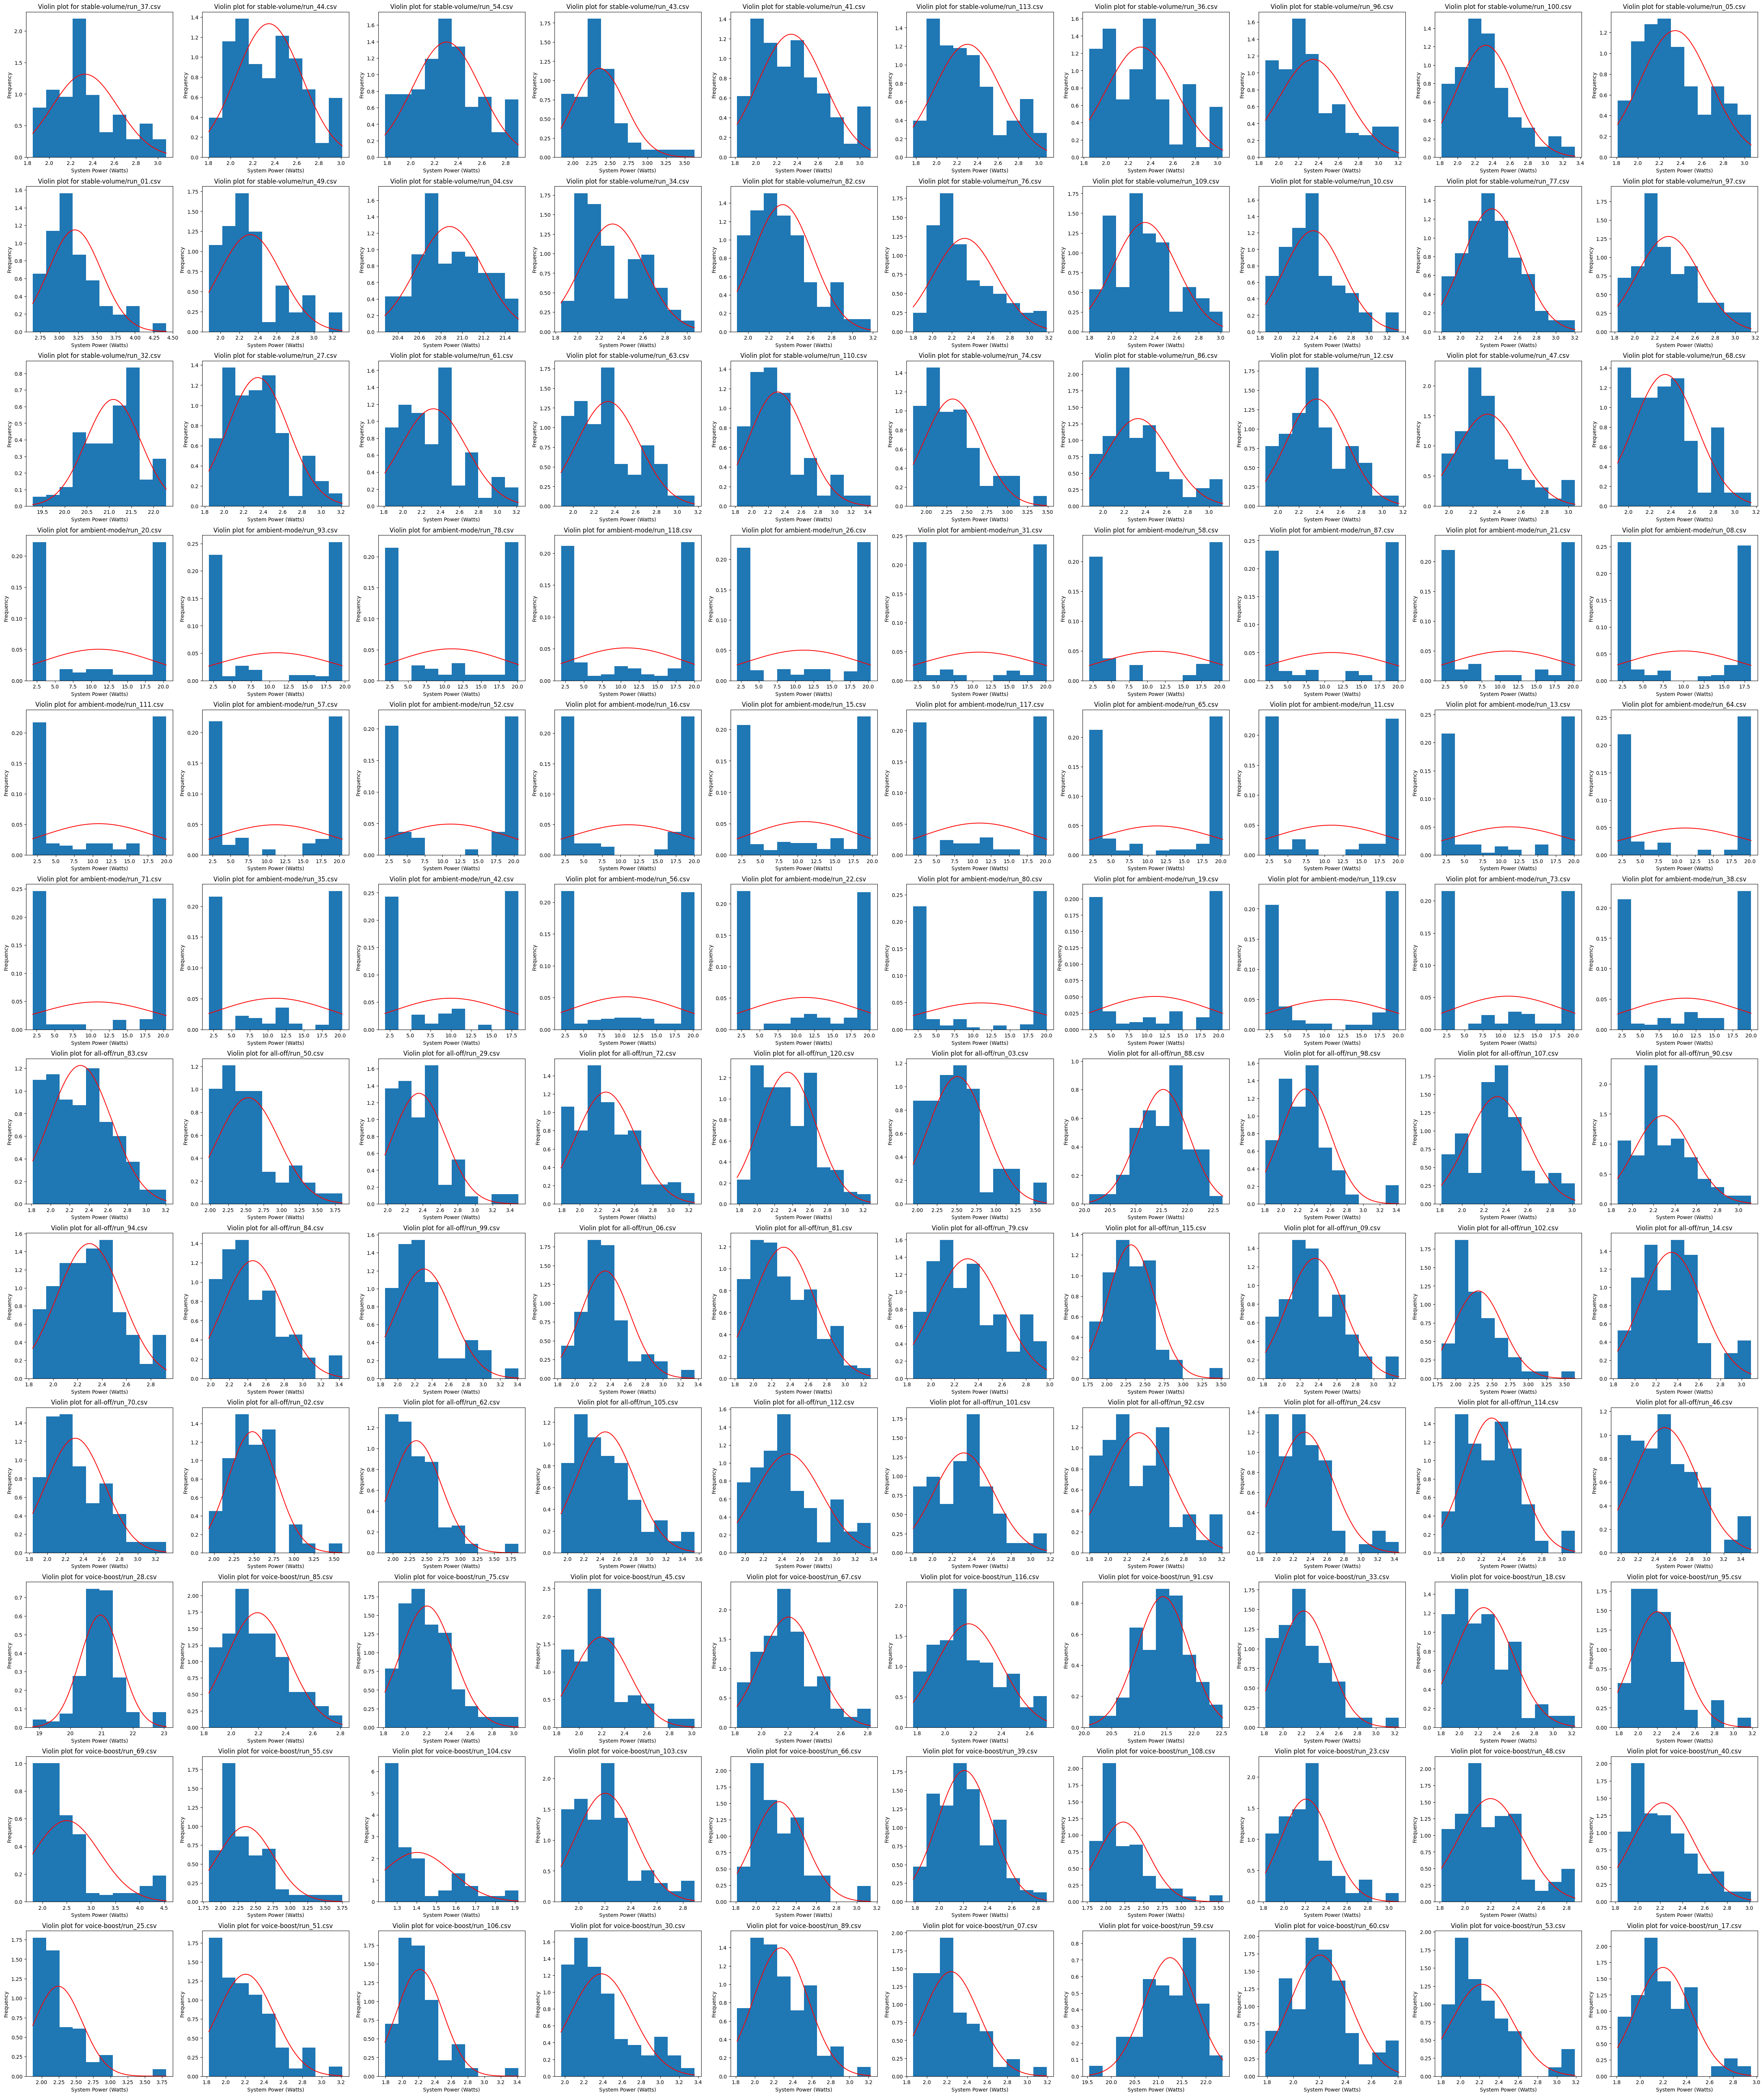

In [34]:
fig, plots = plt.subplots(nrows = 3 * len(QUALITY_DIRECTORIES), 
                               ncols = len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")) // 3,
                               figsize =(6 * len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")) // 3, 6 * len(QUALITY_DIRECTORIES) * 3))
plots = plots.flatten()

for idx, (f, df) in enumerate(normalised_dataframes.items()): 
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_xlabel('System Power (Watts)')
    ax.set_ylabel('Frequency')
    ax.hist(df['SYSTEM_POWER (Watts)'], density=True)
    mu, std = norm.fit(df['SYSTEM_POWER (Watts)'])
    x = np.linspace(df['SYSTEM_POWER (Watts)'].min(), df['SYSTEM_POWER (Watts)'].max(), 200)
    p = norm.pdf(x, mu, std)
    
    ax.plot(x, p, 'r')

# Exploring Results - Avearges & Medians

## Initial Average results

In [35]:
res = {}
for dir in QUALITY_DIRECTORIES: res[dir] = []
for file, df in dataframes.items(): 
    average = df['SYSTEM_POWER (Watts)'].mean()
    f = file.split("/")[0]
    res[f].append(average)

avg_df = pd.DataFrame(res)
avg_df

,stable-volume,ambient-mode,all-off,voice-boost
0,2.392537,11.050754,2.373315,20.942928
1,2.346497,10.866723,2.592098,2.212972
2,2.301912,10.997346,2.410846,2.243411
3,2.404069,10.814990,2.341999,2.260713
4,2.394155,11.130317,2.409820,2.224439
5,2.303528,10.916018,2.560027,2.181522
6,2.382210,11.336967,21.442560,21.363550
7,2.366233,11.014774,2.341205,2.271442
8,2.386653,11.038251,2.321376,2.310536
9,2.395648,9.946009,2.305785,2.243081


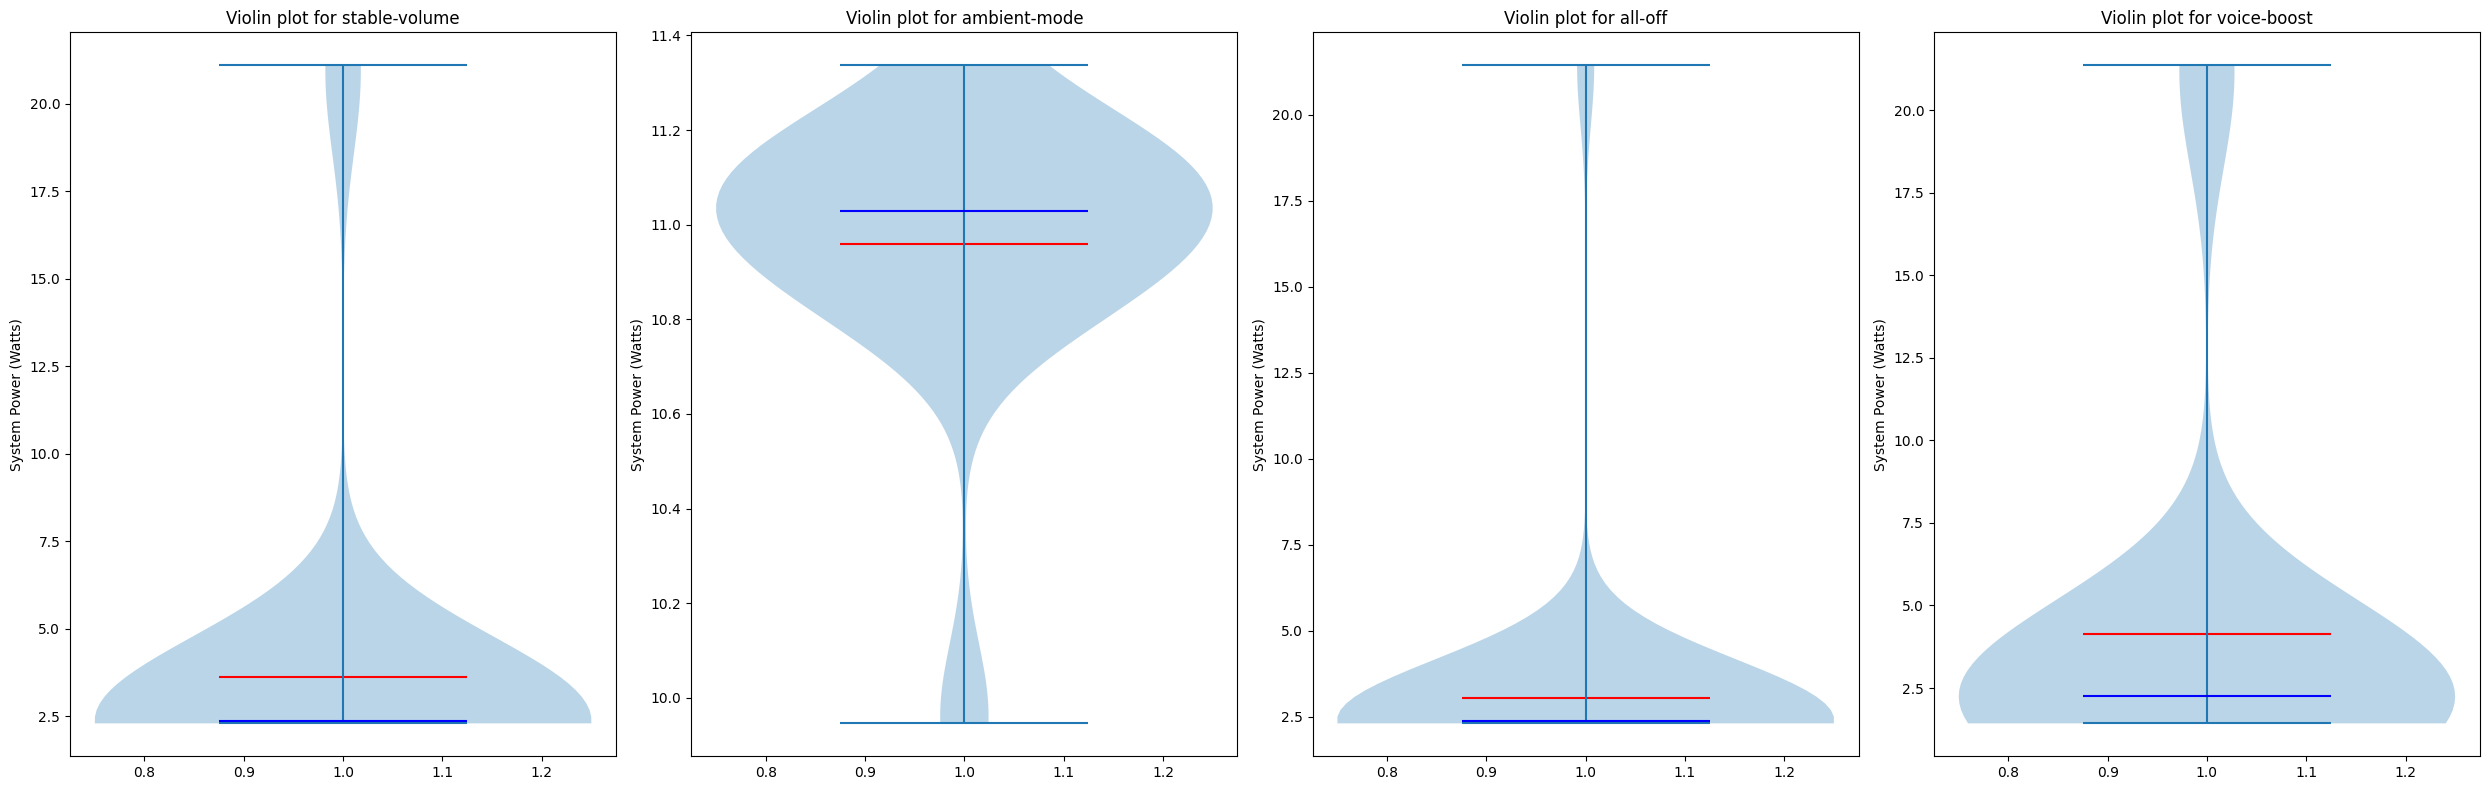

In [36]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, 2 * len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    parts = ax.violinplot(avg_df[f], showmeans=True, showmedians=True)
    parts['cmeans'].set_color('red')
    parts['cmedians'].set_color('blue')    

plt.tight_layout()
plt.show()

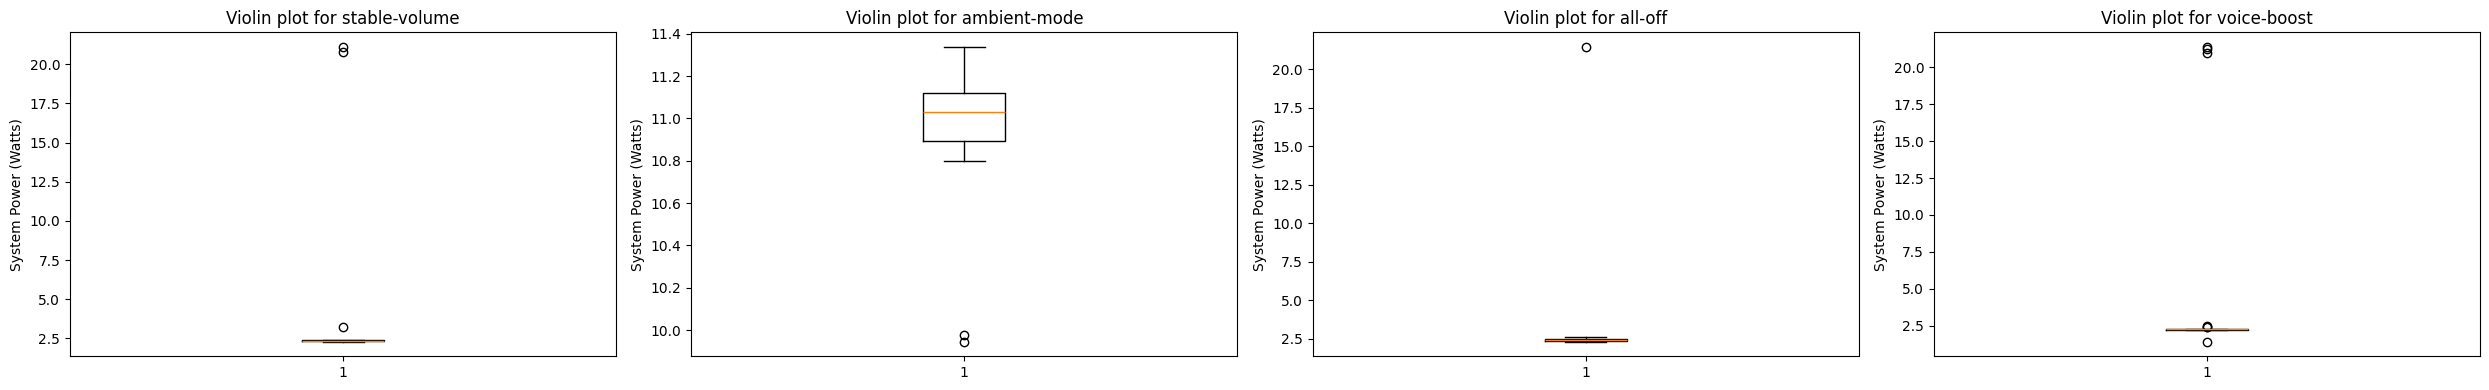

In [37]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    ax.boxplot(avg_df[f])
    
plt.tight_layout()
plt.show()

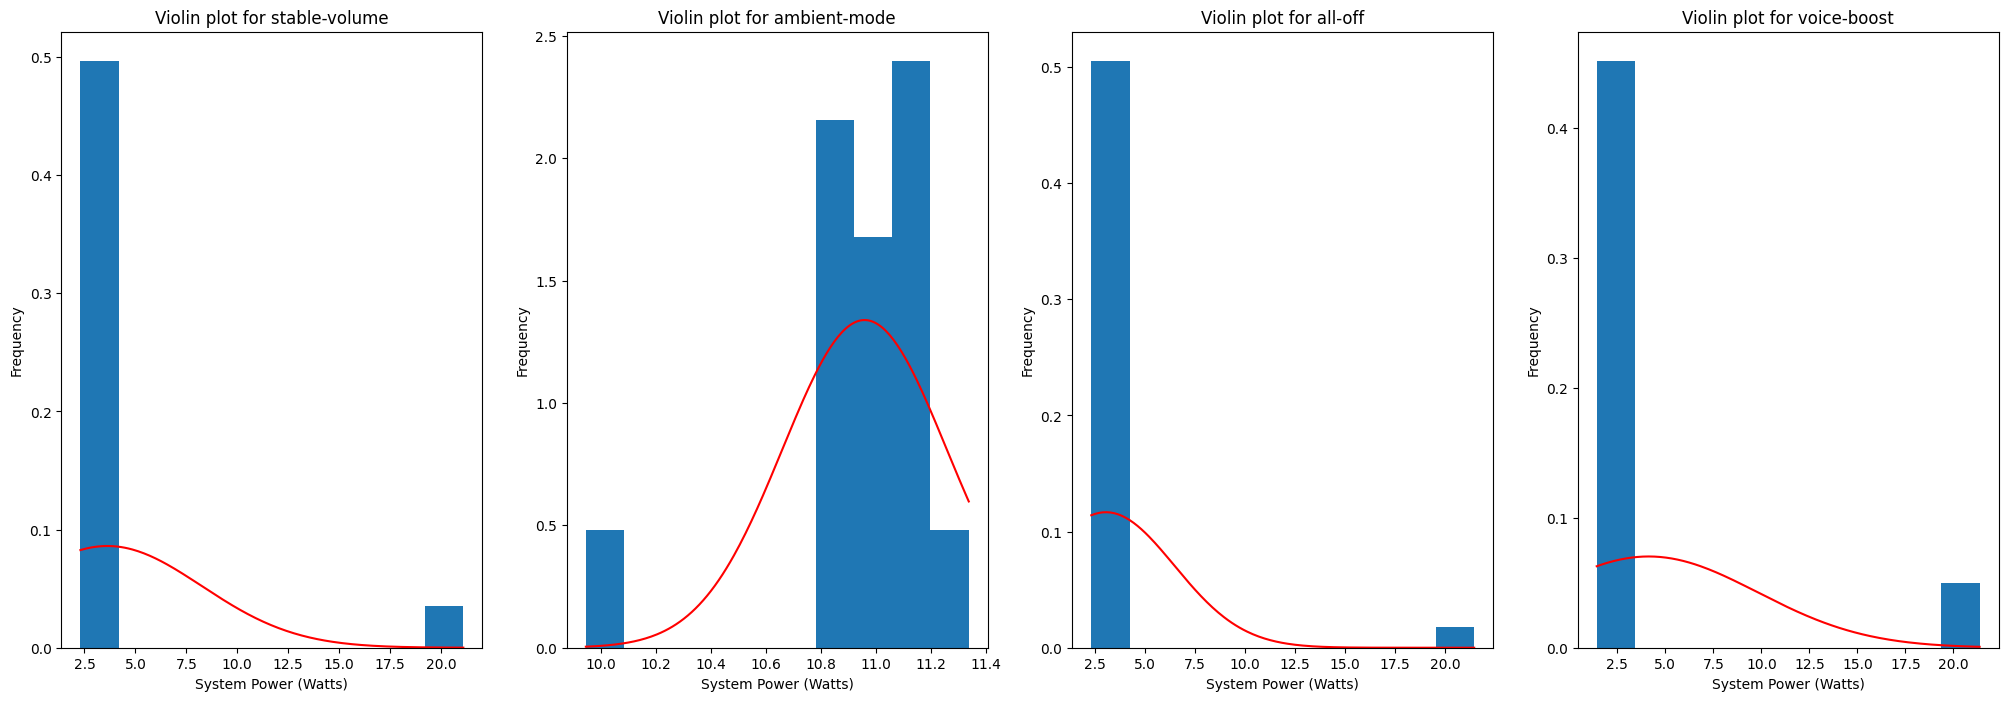

In [38]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, 2 * len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_xlabel('System Power (Watts)')
    ax.set_ylabel('Frequency')
    ax.hist(avg_df[f], density=True)
    mu, std = norm.fit(avg_df[f])
    x = np.linspace(avg_df[f].min(), avg_df[f].max(), 200)
    p = norm.pdf(x, mu, std)
    
    ax.plot(x, p, 'r')

### Normalised Average Results 

In [39]:
for f in avg_df.columns:
    stats, p_val = shapiro(avg_df[f])

    print(f"With p-val {p_val}, the data in {f} is {'NOT NORMAL' if p_val < 0.05 else 'NORMAL'}\n==============================================================")

With p-val 5.94505968096356e-11, the data in stable-volume is NOT NORMAL
With p-val 2.2635137372250636e-06, the data in ambient-mode is NOT NORMAL
With p-val 1.0273136909214146e-11, the data in all-off is NOT NORMAL
With p-val 2.770963439431895e-10, the data in voice-boost is NOT NORMAL


In [40]:
norm_avg_df = {}
for idx, f in enumerate(QUALITY_DIRECTORIES):
    mean = avg_df[f].mean()
    std = avg_df[f].std()
    outlier = []
    max_diff = 0
    print(f"3x std: {3 * std} | mean: {mean}")
    for idx, val in enumerate(avg_df[f]): 
        diff = mean - val
        abs = np.abs(diff)
        if abs > max_diff: max_diff = abs
        if abs > 3*std: 
            print(f"Found outlier at {idx}")
            outlier.append(idx)

    print(f"Maximum difference found: {max_diff}")
    n_df = avg_df[f].drop(index=outlier)
    norm_avg_df[f] = n_df
    print("===============================================")
norm_avg_df = pd.DataFrame(norm_avg_df)
norm_avg_df

3x std: 14.136337098417638 | mean: 3.6255696632343732
Found outlier at 12
Found outlier at 20
Maximum difference found: 17.470242200301087
3x std: 0.9094461754877902 | mean: 10.9584118921019
Found outlier at 9
Found outlier at 22
Maximum difference found: 1.0124032388367432
3x std: 10.431457752370518 | mean: 3.037033427703504
Found outlier at 6
Maximum difference found: 18.405526256971264
3x std: 17.334254364868457 | mean: 4.134697502634116
Maximum difference found: 17.228852198492874


,stable-volume,ambient-mode,all-off,voice-boost
0,2.392537,11.050754,2.373315,20.942928
1,2.346497,10.866723,2.592098,2.212972
2,2.301912,10.997346,2.410846,2.243411
3,2.404069,10.814990,2.341999,2.260713
4,2.394155,11.130317,2.409820,2.224439
5,2.303528,10.916018,2.560027,2.181522
6,2.382210,11.336967,NaN,21.363550
7,2.366233,11.014774,2.341205,2.271442
8,2.386653,11.038251,2.321376,2.310536
9,2.395648,NaN,2.305785,2.243081


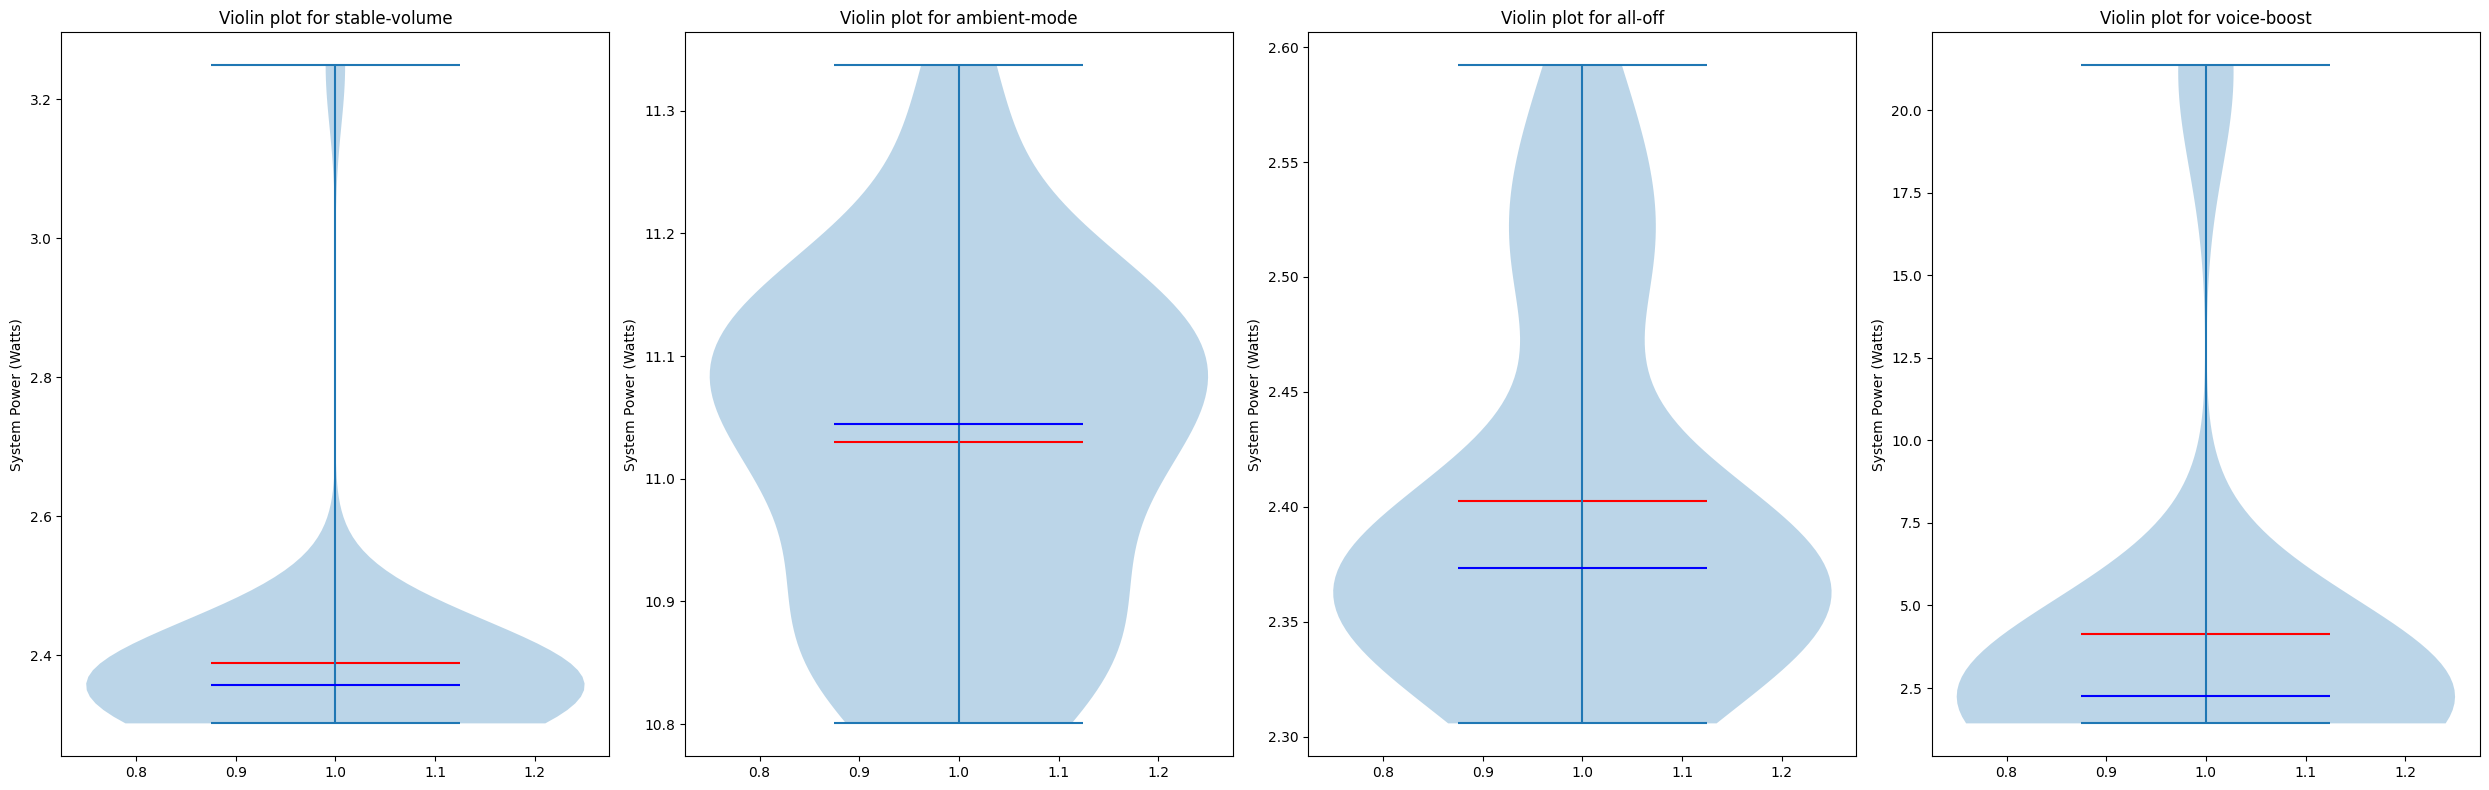

In [41]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, 2 * len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    parts = ax.violinplot(norm_avg_df[f].dropna(), showmeans=True, showmedians=True)
    parts['cmeans'].set_color('red')
    parts['cmedians'].set_color('blue')    

plt.tight_layout()
plt.show()


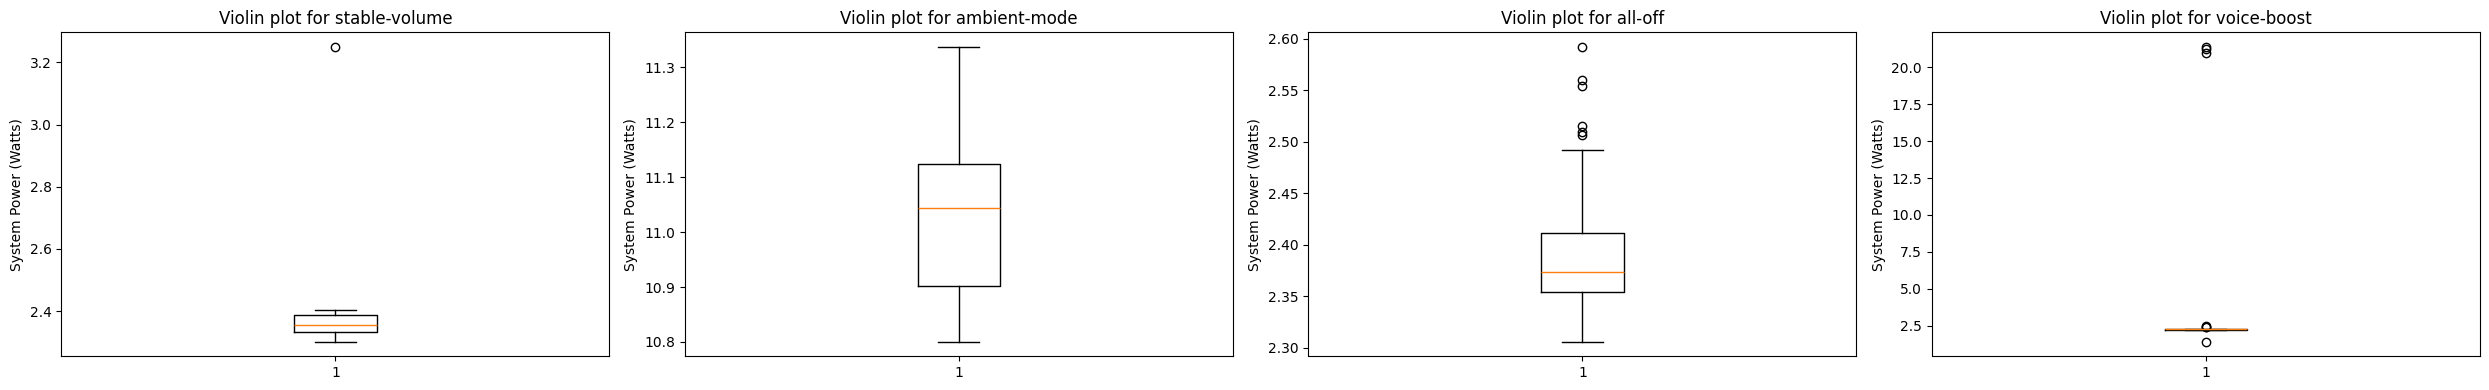

In [42]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    ax.boxplot(norm_avg_df[f].dropna())
    
plt.tight_layout()
plt.show()

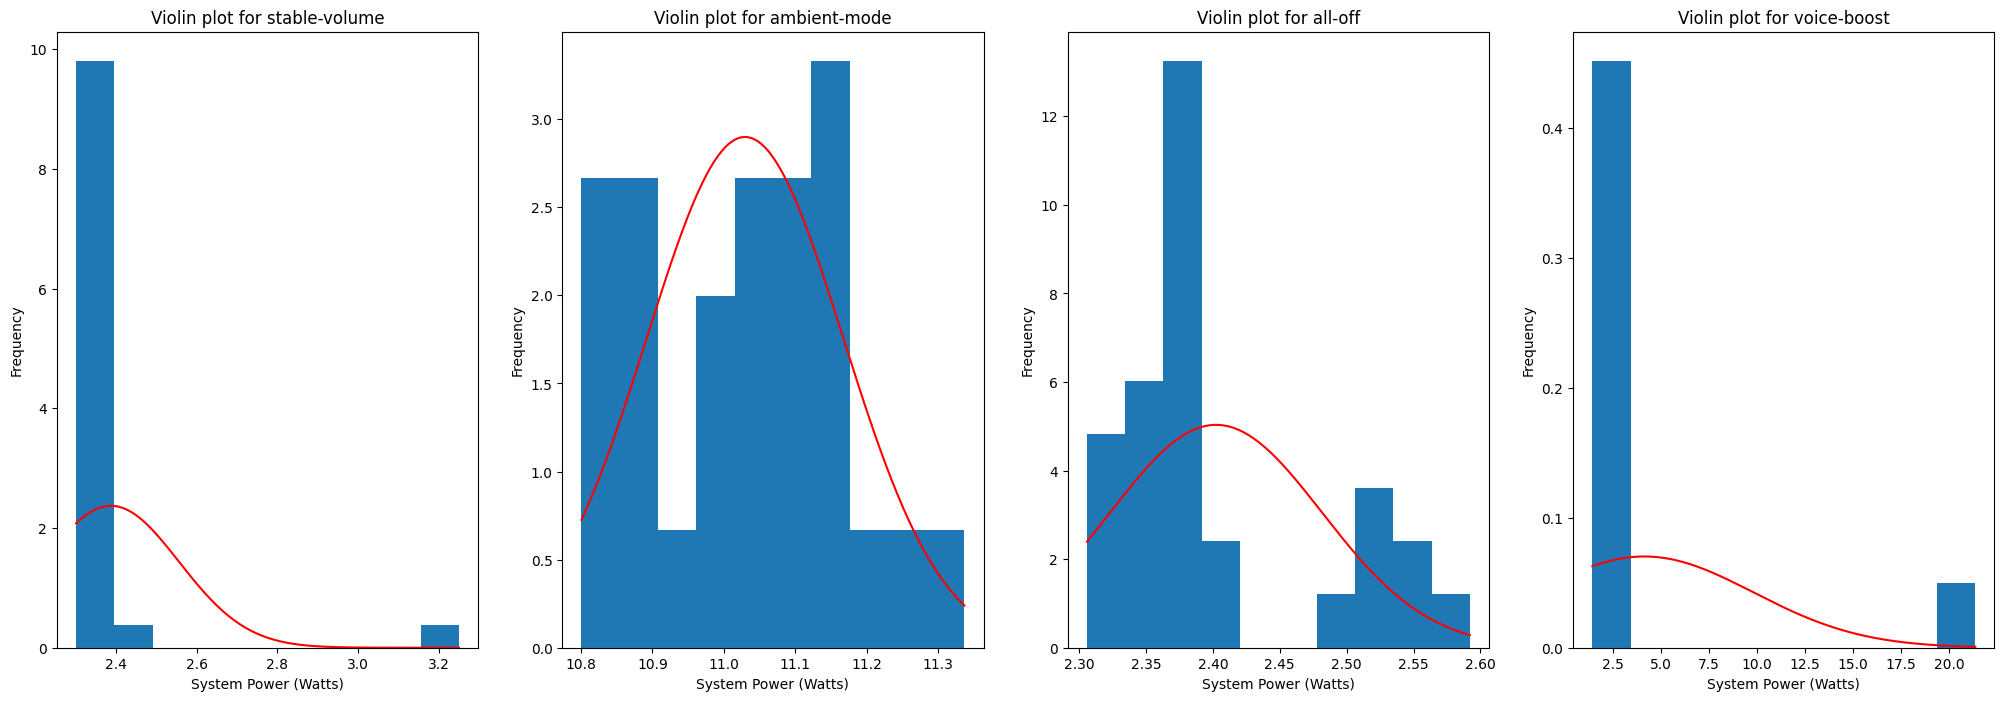

In [43]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, 2 * len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_xlabel('System Power (Watts)')
    ax.set_ylabel('Frequency')
    ax.hist(norm_avg_df[f].dropna(), density=True)
    mu, std = norm.fit(norm_avg_df[f].dropna())
    x = np.linspace(norm_avg_df[f].dropna().min(), norm_avg_df[f].dropna().max(), 200)
    p = norm.pdf(x, mu, std)
    
    ax.plot(x, p, 'r')

## Initial Median Results

In [44]:
res = {}
for dir in QUALITY_DIRECTORIES: res[dir] = []
for file, df in dataframes.items(): 
    med = df['SYSTEM_POWER (Watts)'].median()
    f = file.split("/")[0]
    res[f].append(med)

med_df = pd.DataFrame(res)
med_df

,stable-volume,ambient-mode,all-off,voice-boost
0,2.284851,10.352597,2.305974,20.912916
1,2.346132,8.885894,2.511062,2.151232
2,2.307927,11.622122,2.308157,2.166873
3,2.335582,10.762320,2.238100,2.153532
4,2.293791,11.211896,2.324438,2.194746
5,2.268544,8.777304,2.461452,2.140203
6,2.284665,8.779414,21.517012,21.422541
7,2.259166,9.025780,2.294510,2.172617
8,2.290750,10.750274,2.308487,2.203908
9,2.273633,7.797339,2.230938,2.167793


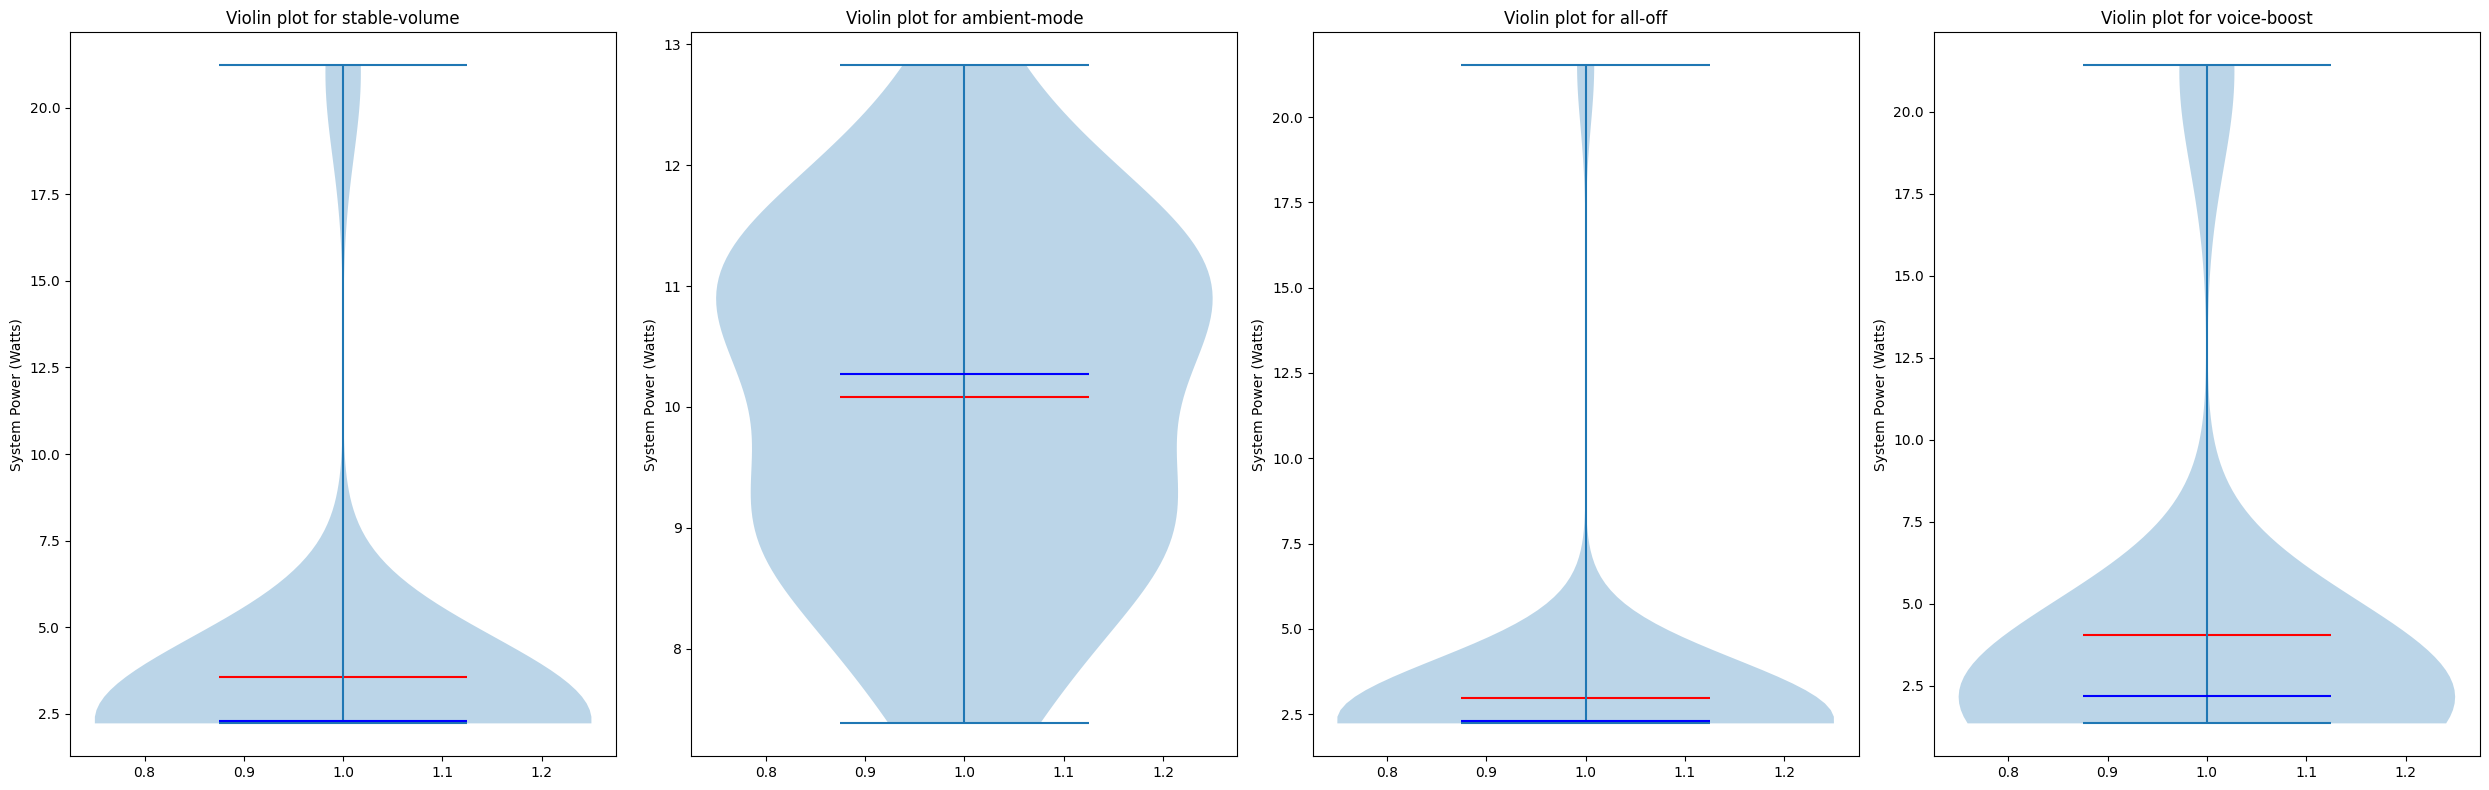

In [45]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, 2 * len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    parts = ax.violinplot(med_df[f], showmeans=True, showmedians=True)
    parts['cmeans'].set_color('red')
    parts['cmedians'].set_color('blue')    

plt.tight_layout()
plt.show()

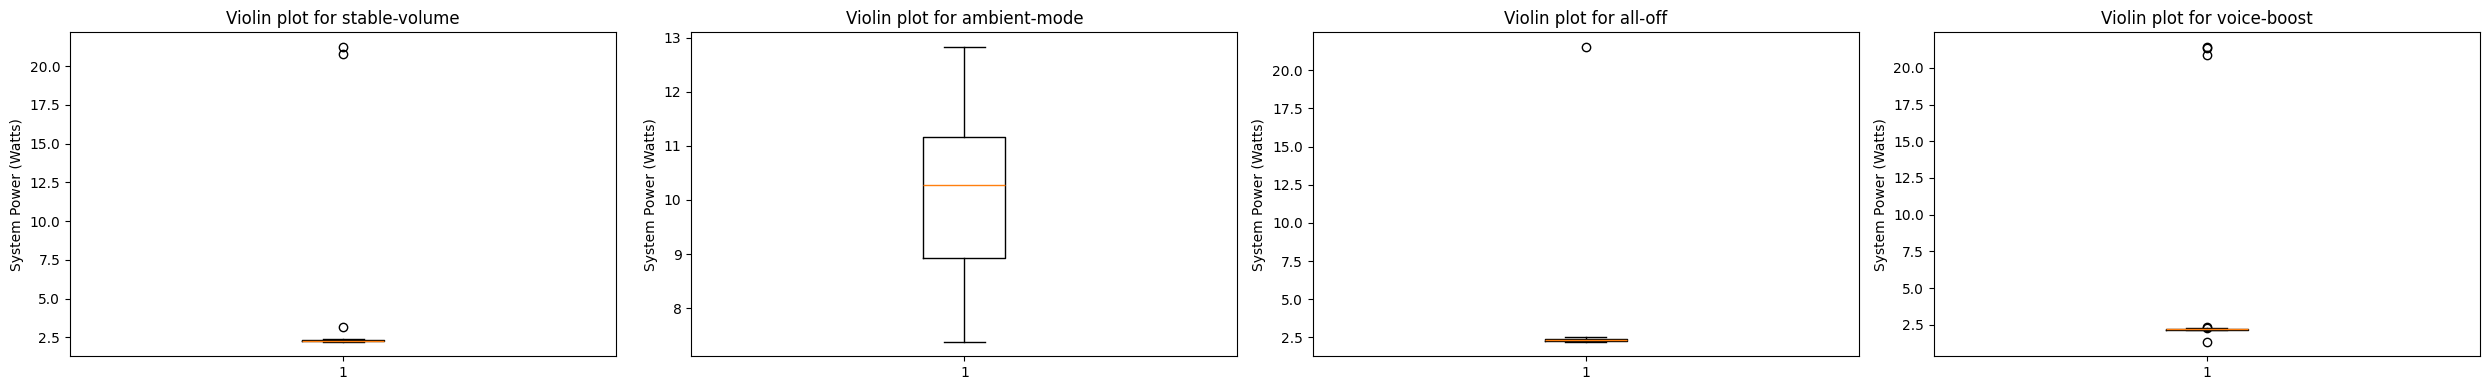

In [46]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    ax.boxplot(med_df[f])
    
plt.tight_layout()
plt.show()

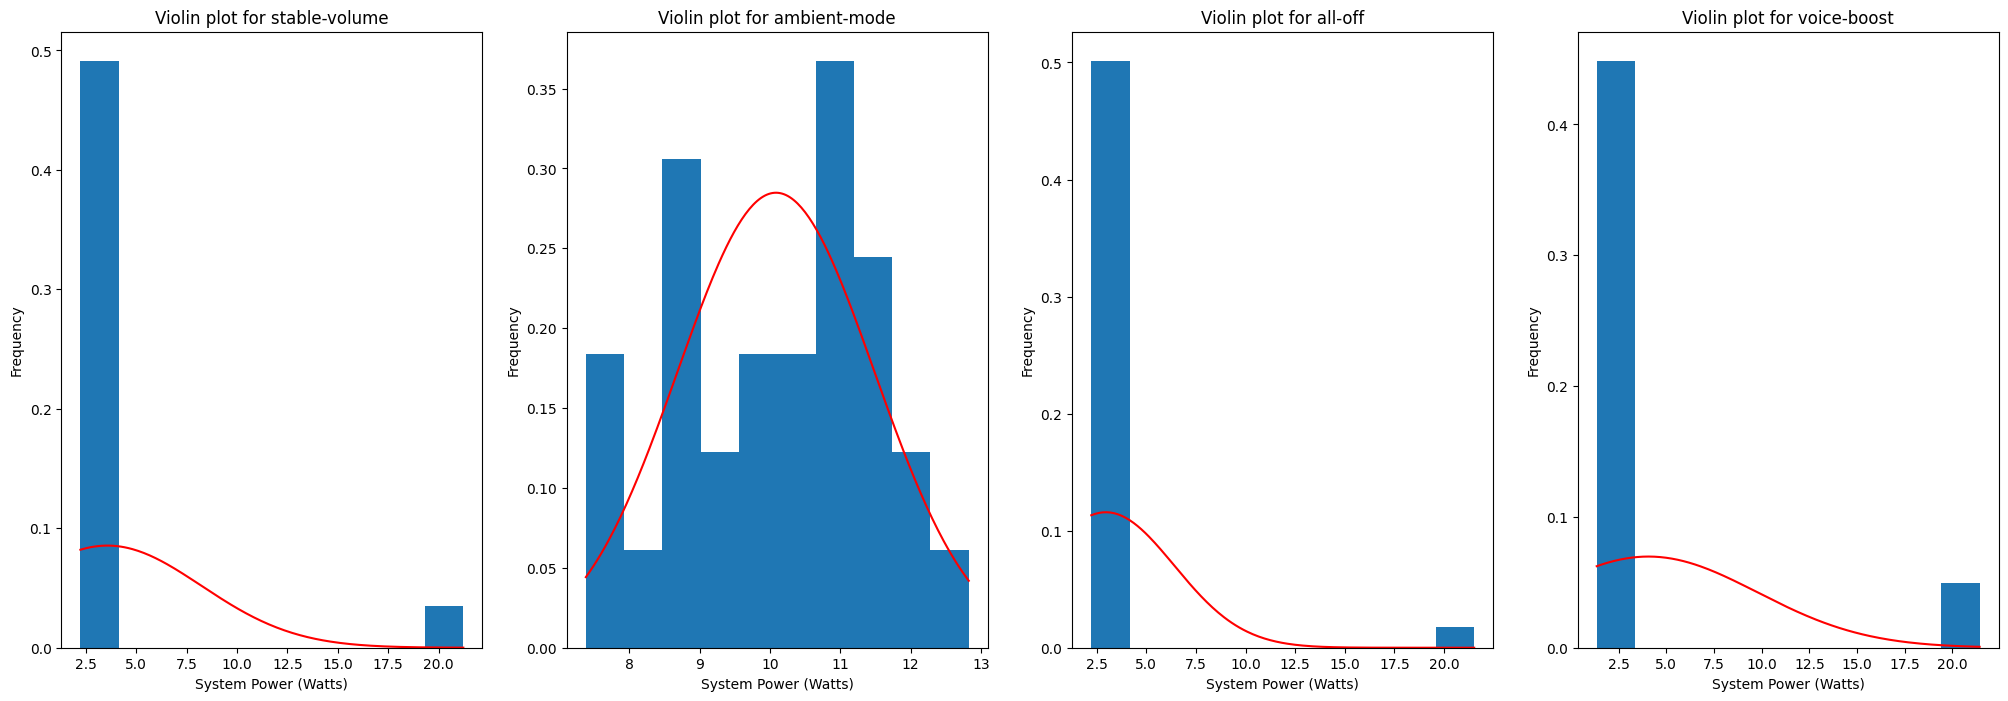

In [47]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, 2 * len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_xlabel('System Power (Watts)')
    ax.set_ylabel('Frequency')
    ax.hist(med_df[f], density=True)
    mu, std = norm.fit(med_df[f])
    x = np.linspace(med_df[f].min(), med_df[f].max(), 200)
    p = norm.pdf(x, mu, std)
    
    ax.plot(x, p, 'r')

### Normalised Median Results

In [48]:
for f in med_df.columns:
    stats, p_val = shapiro(med_df[f])

    print(f"With p-val {p_val}, the data in {f} is {'NOT NORMAL' if p_val < 0.05 else 'NORMAL'}\n==============================================================")

With p-val 6.005485871573072e-11, the data in stable-volume is NOT NORMAL
With p-val 0.5373672670237615, the data in ambient-mode is NORMAL
With p-val 1.0188278587175953e-11, the data in all-off is NOT NORMAL
With p-val 2.633919403335324e-10, the data in voice-boost is NOT NORMAL


In [49]:
norm_med_df = {}
for idx, f in enumerate(QUALITY_DIRECTORIES):
    mean = med_df[f].mean()
    std = med_df[f].std()
    outlier = []
    max_diff = 0
    print(f"3x std: {3 * std} | mean: {mean}")
    for idx, val in enumerate(med_df[f]): 
        diff = mean - val
        abs = np.abs(diff)
        if abs > max_diff: max_diff = abs
        if abs > 3*std: 
            print(f"Found outlier at {idx}")
            outlier.append(idx)

    print(f"Maximum difference found: {max_diff}")
    n_df = med_df[f].drop(index=outlier)
    norm_med_df[f] = n_df
    print("===============================================")
norm_med_df = pd.DataFrame(norm_med_df)
norm_med_df

3x std: 14.237402406435576 | mean: 3.563885335127513
Found outlier at 12
Found outlier at 20
Maximum difference found: 17.66361176570257
3x std: 4.27447316735233 | mean: 10.085685380299886
Maximum difference found: 2.742390028635663
3x std: 10.514777476937404 | mean: 2.9639928102493287
Found outlier at 6
Maximum difference found: 18.55301883220672
3x std: 17.466443419688424 | mean: 4.063637987772624
Maximum difference found: 17.35890267690023


,stable-volume,ambient-mode,all-off,voice-boost
0,2.284851,10.352597,2.305974,20.912916
1,2.346132,8.885894,2.511062,2.151232
2,2.307927,11.622122,2.308157,2.166873
3,2.335582,10.762320,2.238100,2.153532
4,2.293791,11.211896,2.324438,2.194746
5,2.268544,8.777304,2.461452,2.140203
6,2.284665,8.779414,NaN,21.422541
7,2.259166,9.025780,2.294510,2.172617
8,2.290750,10.750274,2.308487,2.203908
9,2.273633,7.797339,2.230938,2.167793


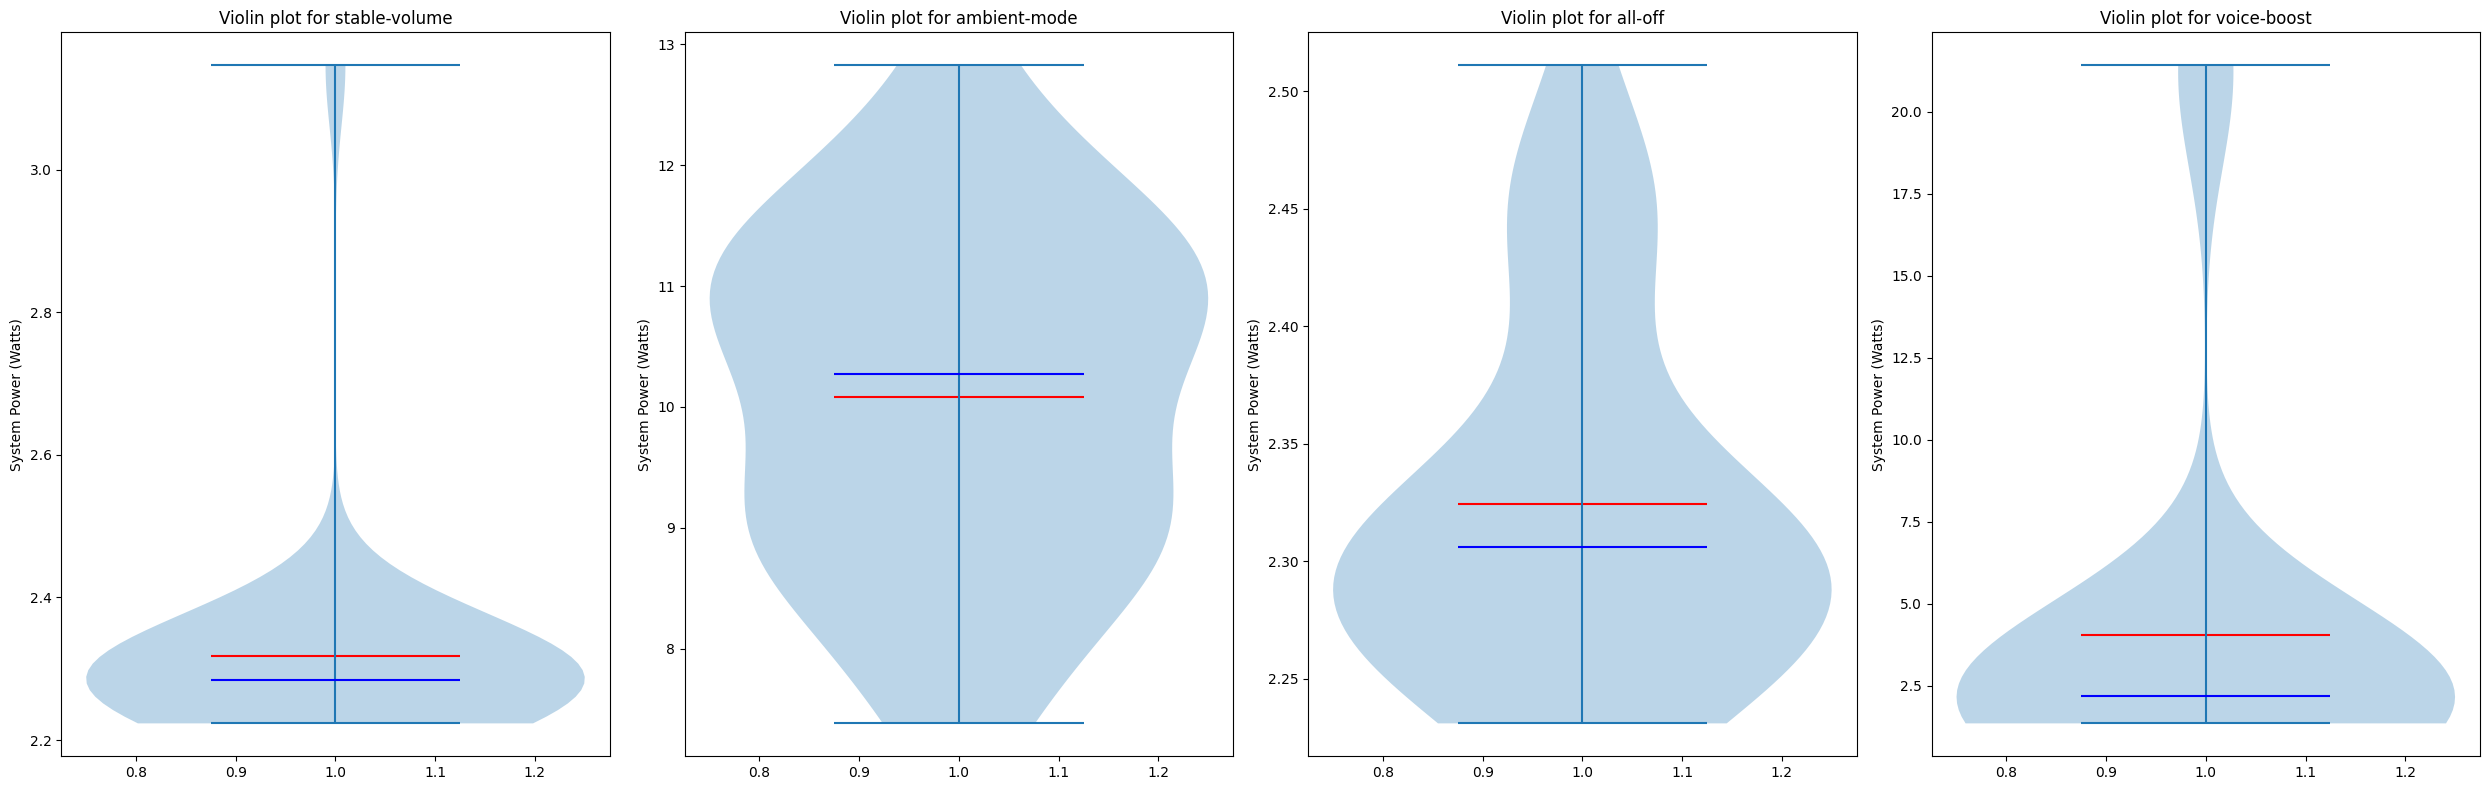

In [50]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, 2 * len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    parts = ax.violinplot(norm_med_df[f].dropna(), showmeans=True, showmedians=True)
    parts['cmeans'].set_color('red')
    parts['cmedians'].set_color('blue')    

plt.tight_layout()
plt.show()


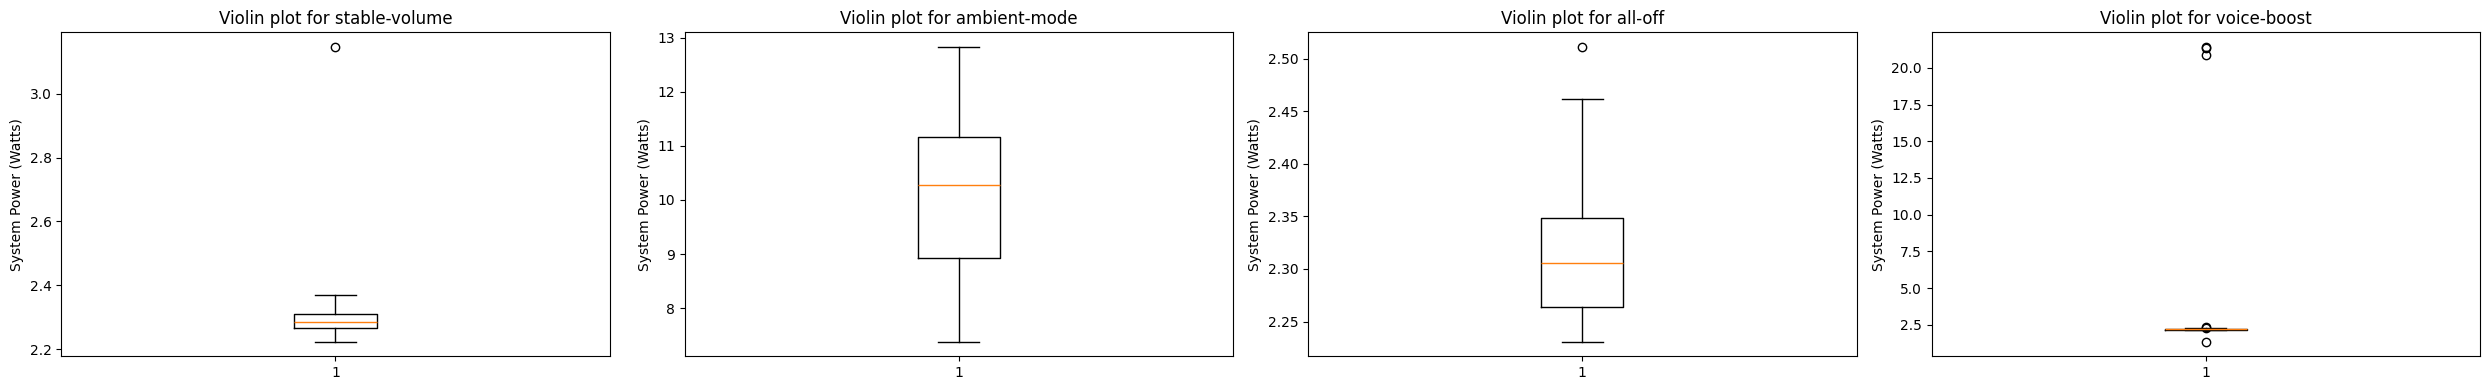

In [51]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    ax.boxplot(norm_med_df[f].dropna())
    
plt.tight_layout()
plt.show()

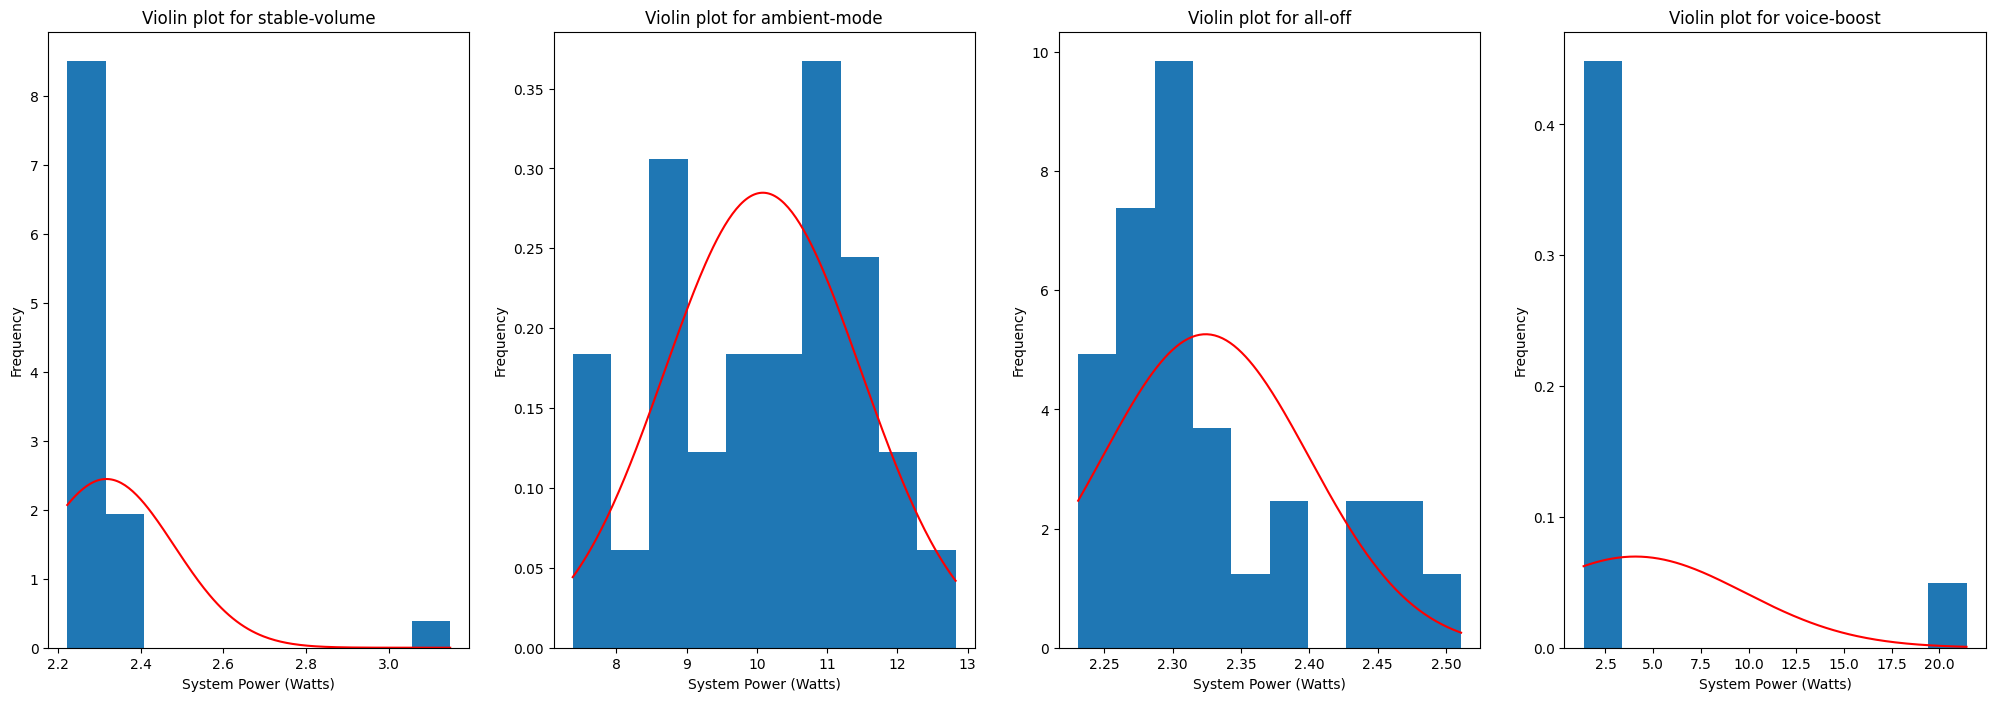

In [52]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, 2 * len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_xlabel('System Power (Watts)')
    ax.set_ylabel('Frequency')
    ax.hist(norm_med_df[f].dropna(), density=True)
    mu, std = norm.fit(norm_med_df[f].dropna())
    x = np.linspace(norm_med_df[f].dropna().min(), norm_med_df[f].dropna().max(), 200)
    p = norm.pdf(x, mu, std)
    
    ax.plot(x, p, 'r')